<img src="https://www.pucsp.br/sites/default/files/download/brasao-PUCSP-assinatura-principal-RGB.png" style="float:right;" width="150px">

# Ciências da Computação [》](https://www.pucsp.br/graduacao/ciencia-da-computacao)

## Inteligência Artificial

IA ML (Machine Learning, Aprendizagem de Máquina)

**Objetivo desta aula e LAB explorar os modelos de Redes Neurais Artificiais (ANN - Artificial Neural Network) com Scikit-Learn em Python, sobre os dados da Lego**

Inteligência Artificial - ML com Scikit-learn

PARTE II - LAB

### Equipe

- Luís Augusto Coelho de Souza | RA00331675
- Guilherme Schnekenberg Teixeira | RA00336189

### Dados (LEGO)

LEGO sets released from 1970 to 2022, including details on each set's theme, pieces, recommended age, retail price, and image.

https://mavenanalytics.io/data-playground/lego-sets


## TODO

LAB:

EM DUPLAS (Pairing)<br>
Entrega amanhã (24 horas) em atividade no MS Teams
- Entregar o link do .ipynb no GitHub

- Baixar os dados
- Carregar em data frame Pandas
- Exibir visualmente os dados faltantes
- Organizar e limpar os dados
- Completar os kits de lego (Lego Sets) sem preço
   - Modelagem: Usando redes neurais artificial (ANN)
   - Scikit-learn
- Realizar análise e visualizações
   

Baixando dados do site, com o comando do Linux `wget` e o magic **!**

In [148]:
!wget https://maven-datasets.s3.amazonaws.com/LEGO+Sets/LEGO+Sets.zip

--2026-09-29 20:24:17--  https://maven-datasets.s3.amazonaws.com/LEGO+Sets/LEGO+Sets.zip
Resolving maven-datasets.s3.amazonaws.com (maven-datasets.s3.amazonaws.com)... 52.217.162.42, 16.15.237.238, 52.217.73.24, ...
Connecting to maven-datasets.s3.amazonaws.com (maven-datasets.s3.amazonaws.com)|52.217.162.42|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 536301 (524K) [application/zip]
Saving to: ‘LEGO+Sets.zip.1’

LEGO+Sets.zip.1     100%[===================>] 523.73K  --.-KB/s    in 0.02s   

2026-09-29 20:24:17 (25.1 MB/s) - ‘LEGO+Sets.zip.1’ saved [536301/536301]



Descompactando arquivo zip

In [149]:
!unzip *.zip

Archive:  LEGO+Sets.zip
replace lego_sets.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: lego_sets.csv           
replace lego_sets_data_dictionary.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: lego_sets_data_dictionary.csv  


Listando os arquivos na pasta atual

In [150]:
!ls -l

total 6540
-rw-r--r-- 1 root root   96544 Sep 29 19:19 brickset_cache.json
-rw-r--r-- 1 root root   74997 Sep 29 16:42 distribution_agerange_min.png
-rw-r--r-- 1 root root   57622 Sep 29 15:29 distribution_log_minifigs.png
-rw-r--r-- 1 root root   71174 Sep 29 14:57 distribution_log_pieces.png
-rw-r--r-- 1 root root   65380 Sep 29 14:51 distribution_log_price.png
-rw-r--r-- 1 root root   56489 Sep 29 15:28 distribution_minifigs.png
-rw-r--r-- 1 root root   50254 Sep 29 14:57 distribution_pieces.png
-rw-r--r-- 1 root root   59172 Sep 29 14:04 distribution_US_retailPrice.png
-rw-r--r-- 1 root root   64612 Sep 29 14:48 distribution_year.png
-rw-r--r-- 1 root root   74425 Sep 29 20:11 known_vs_predicted_dist.png
-rw-r--r-- 1 root root 3936470 Jan  3  2024 lego_sets.csv
-rw-r--r-- 1 root root     532 Jan  3  2024 lego_sets_data_dictionary.csv
-rw-r--r-- 1 root root  536301 Jan  3  2024 LEGO+Sets.zip
-rw-r--r-- 1 root root  536301 Jan  3  2024 LEGO+Sets.zip.1
-rw-r--r-- 1 root root   74988 S

Importando LIBs de EDA (Exploratory Data Analisys)


In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


## **Exploratory Data Analysis**



Loading and visualizing the data

In [152]:
lego_df = pd.read_csv('lego_sets.csv')

lego_df.head()

,set_id,name,year,theme,subtheme,themeGroup,category,pieces,minifigs,agerange_min,US_retailPrice,bricksetURL,thumbnailURL,imageURL
0,1-8,Small house set,1970,Minitalia,NaN,Vintage,Normal,67.0,NaN,NaN,NaN,https://brickset.com/sets/1-8,https://images.brickset.com/sets/small/1-8.jpg,https://images.brickset.com/sets/images/1-8.jpg
1,2-8,Medium house set,1970,Minitalia,NaN,Vintage,Normal,109.0,NaN,NaN,NaN,https://brickset.com/sets/2-8,https://images.brickset.com/sets/small/2-8.jpg,https://images.brickset.com/sets/images/2-8.jpg
2,3-6,Medium house set,1970,Minitalia,NaN,Vintage,Normal,158.0,NaN,NaN,NaN,https://brickset.com/sets/3-6,https://images.brickset.com/sets/small/3-6.jpg,https://images.brickset.com/sets/images/3-6.jpg
3,4-4,Large house set,1970,Minitalia,NaN,Vintage,Normal,233.0,NaN,NaN,NaN,https://brickset.com/sets/4-4,https://images.brickset.com/sets/small/4-4.jpg,https://images.brickset.com/sets/images/4-4.jpg
4,4-6,Mini House and Vehicles,1970,Samsonite,Model Maker,Vintage,Normal,NaN,NaN,NaN,NaN,https://brickset.com/sets/4-6,NaN,NaN


In [153]:
lego_df.shape

(18457, 14)

Searching for missing values (nulls)

In [154]:
# show missing values
lego_df.isnull().sum()

,0
set_id,0
name,0
year,0
theme,0
subtheme,3556
themeGroup,2
category,0
pieces,3924
minifigs,10058
agerange_min,11670


#### Visualizing and studing missing values (nulls)

<Axes: >

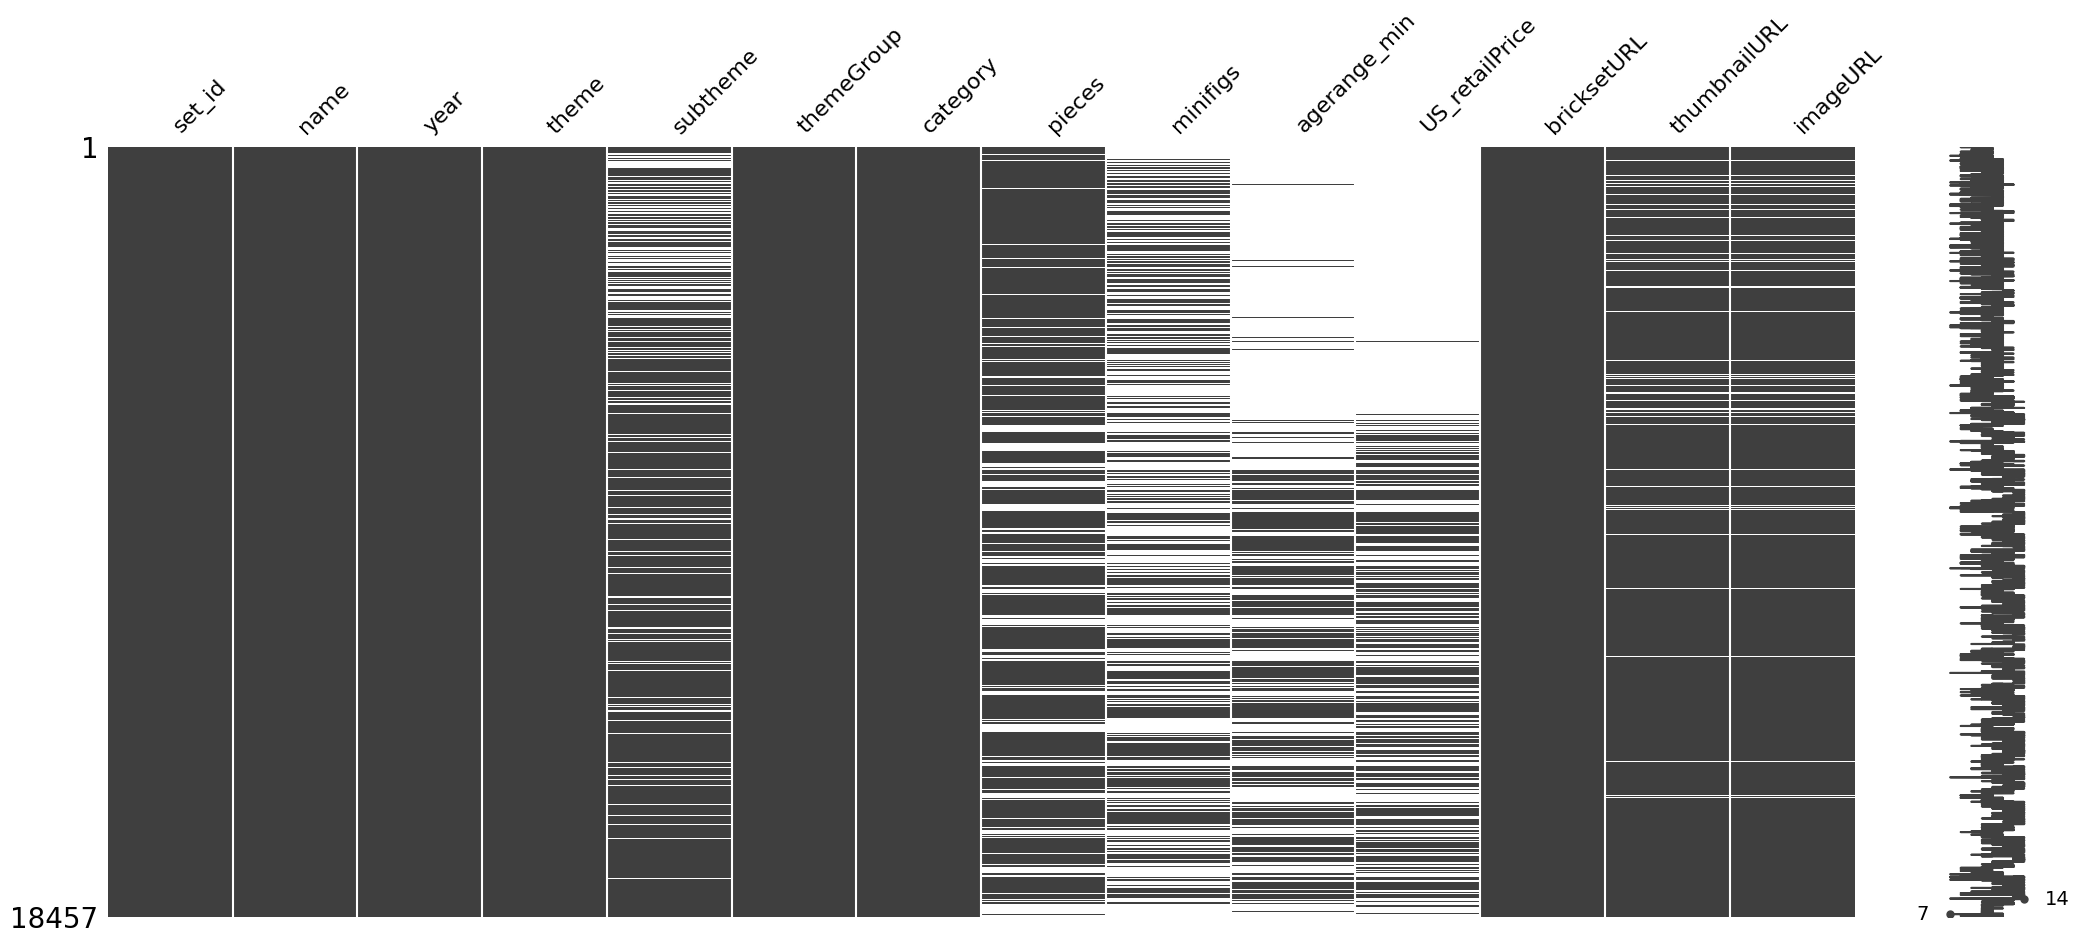

In [155]:
#Visualize missing values
msno.matrix(lego_df)


<Axes: >

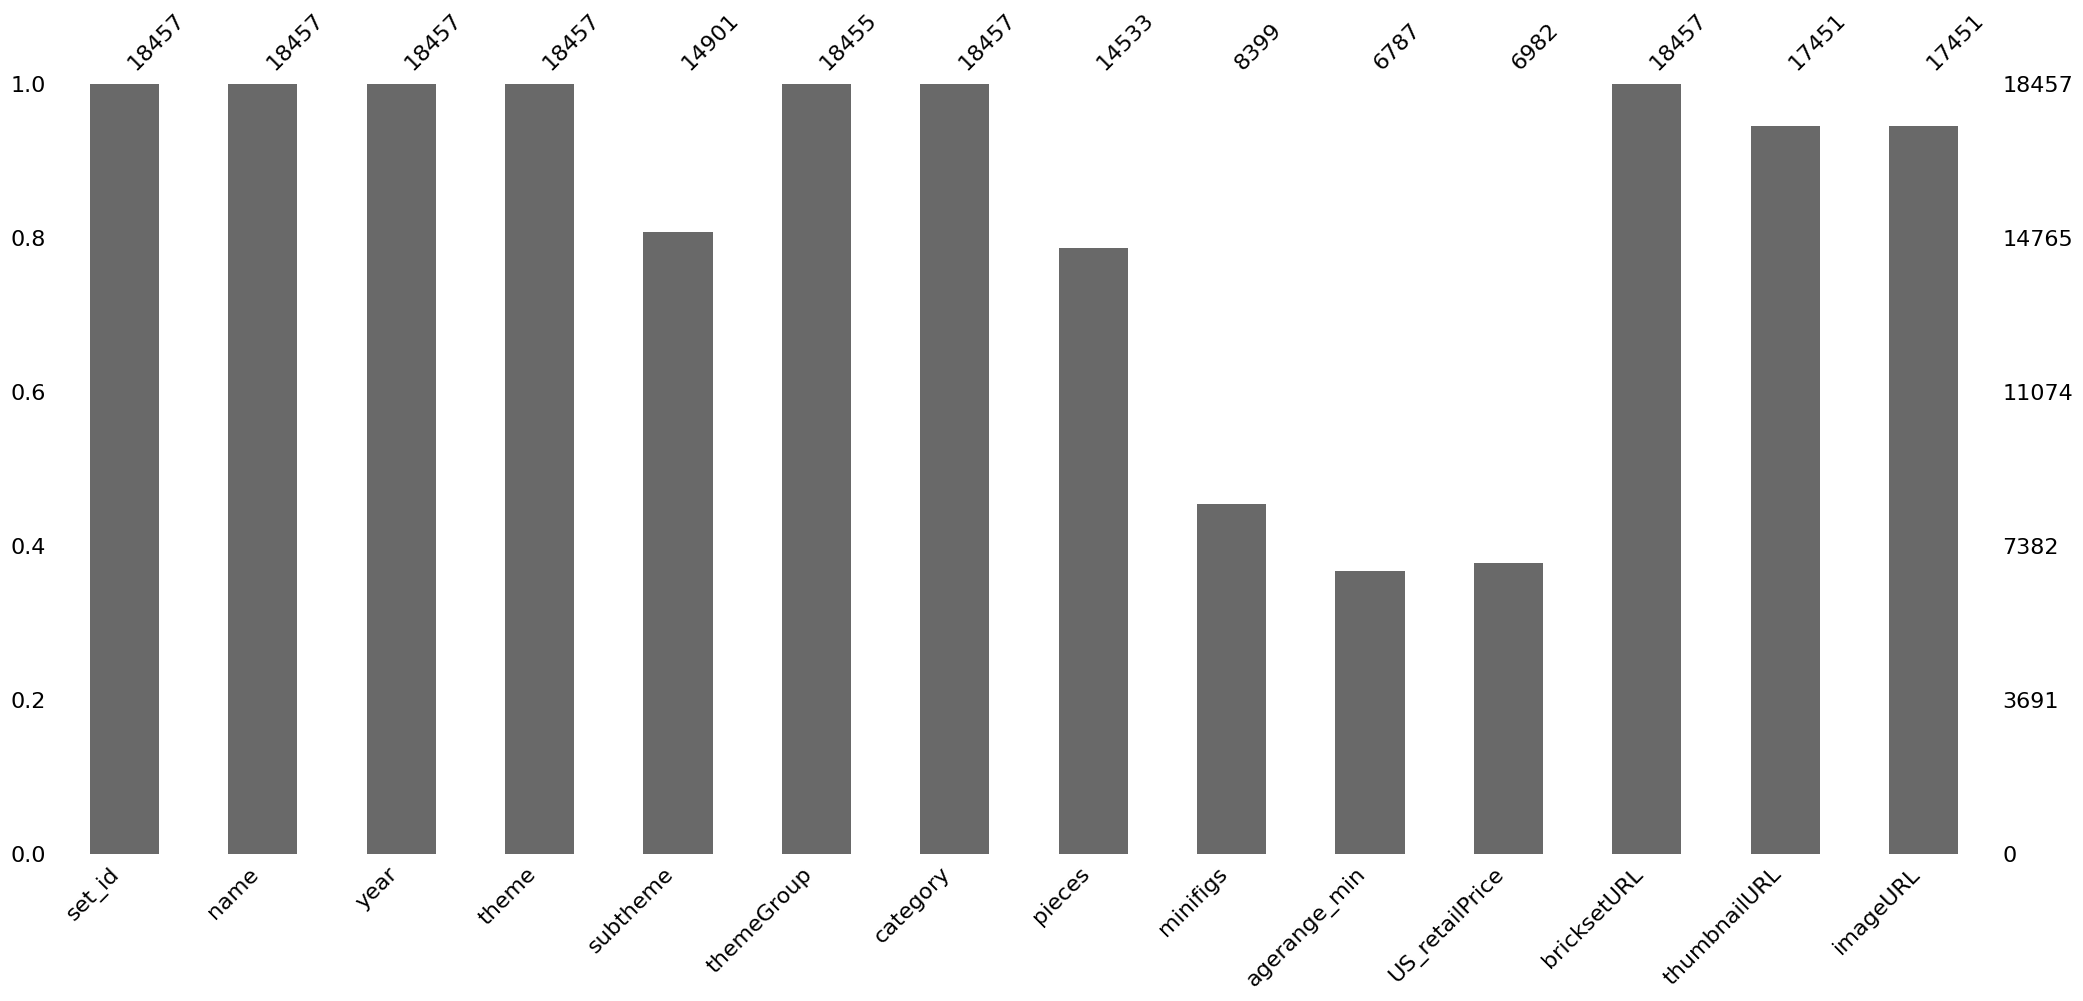

In [156]:
msno.bar(lego_df)


<Axes: >

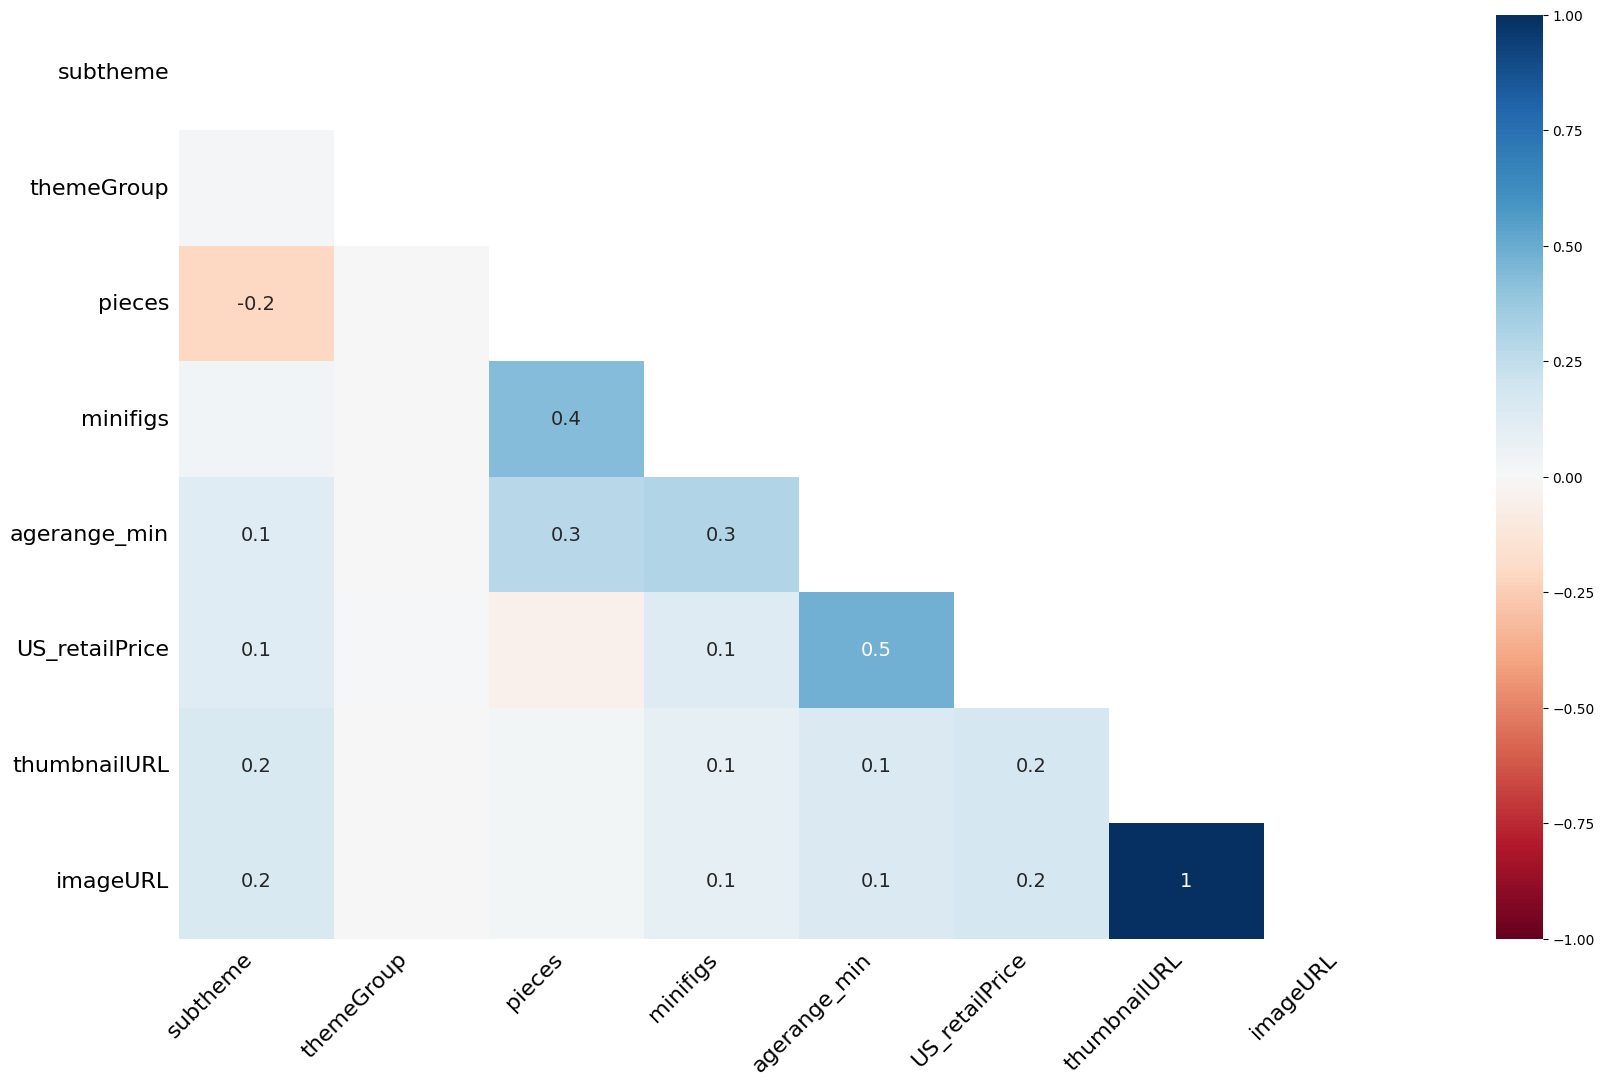

In [157]:
msno.heatmap(lego_df)


#### Correlation between missing values

The matrix shown above allows us to take five key insights:

- There is a strong correlation between missing ImageURL and ThumbnailURL, which would make sense if both are extracted from the same source;
- There is a mildly positive correlation between the missing target variable's values (US_retailPrice) and the agerange_min feature data;
- There is a mildly positive correlation between the missing values of the following features:
  - minifigs and pieces
  - agerange_min and pieces
  - agerange_min and minifigs
- There is a small negative correlation between the missing values of the following features: pieces and subtheme

These insights might help us figure why data is missing and find a better way to use it.

In [158]:
def display_missing_values_cor(df, *cols):
    """
    Displays a v-bar comparison of missing-value patterns across N columns in a DF,
    ordered by number of columns missing (0, 1, 2, ... all).
    """
    names = [c.name for c in cols]
    total = len(df)

    def pattern_info(row_flags):
        missing = [name for name, flag in zip(names, row_flags) if flag]
        n_missing = len(missing)
        if n_missing == 0:
            label = 'None missing'
        elif n_missing == len(names):
            label = 'All missing'
        else:
            label = ' & '.join(missing) + ' only'
        return label, n_missing

    labels_and_counts = [pattern_info(flags) for flags in zip(*cols)]
    labels = [x[0] for x in labels_and_counts]
    n_missing_lookup = dict(labels_and_counts)

    categories = pd.Series(labels).value_counts()

    # sort by n_missing, then alphabetically within same group
    ordered_index = sorted(categories.index, key=lambda lbl: (n_missing_lookup[lbl], lbl))
    categories = categories.reindex(ordered_index)

    fig, ax = plt.subplots(figsize=(8 + len(names), 5))
    color_map = {'None missing': '#55a868', 'All missing': '#c44e52'}
    palette = ['#4c72b0', '#dd8452', '#8172b2', '#937860', '#da8bc3']
    colors = [color_map.get(cat, palette[n_missing_lookup[cat] % len(palette)])
              for cat in categories.index]

    bars = ax.bar(categories.index, categories.values, color=colors)

    for bar, count in zip(bars, categories.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{count:,}\n({count/total:.1%})',
                ha='center', va='bottom', fontsize=10)

    ax.set_ylabel('Number of sets')
    ax.set_title(f'Missingness pattern: {" vs. ".join(names)} (n={total:,})')
    ax.margins(y=0.15)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    fname = 'missingness_' + '_'.join(names) + '.png'
    plt.savefig(fname, dpi=150)
    plt.show()

##### **imageURL and thumbnailURL**

- Correlation value: 1.0

The missingness of `imageURL` and `thumbnailURL` is perfectly correlated, only two patterns appear across all 18,457 rows: either both are present (94.5%, 17451 rows) or both are missing (5.5%, 1006 rows). No row has one without the other, confirming these fields are sourced from the same pipeline or the same underlying image asset, when the source fails to provide an image, it fails for both fields simultaneously.

Since these two columns are functionally redundant from a missingness standpoint, there's no value in treating them as independent predictors or independently imputing one from the other. More importantly, neither is likely relevant to predicting `US_retailPrice` in the first place, they're identifiers/links to images, not descriptive features of the set. Worth confirming with the earlier correlation heatmap, but this pair is probably safe to exclude from the price-imputation model entirely, rather than spend effort reconciling their missingness.

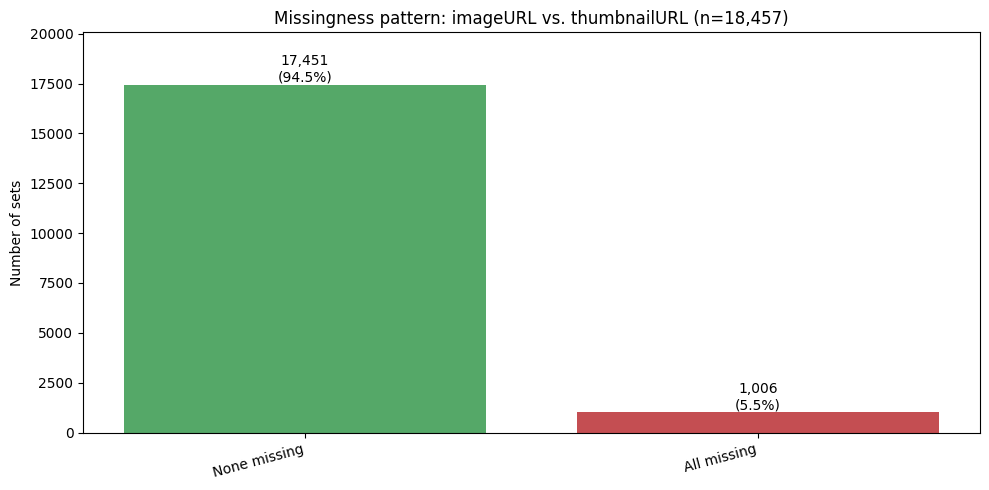

In [159]:
display_missing_values_cor(
    lego_df,
    lego_df['imageURL'].isnull(),
    lego_df['thumbnailURL'].isnull()
)

##### **US_retailPrice and agerange_min**

- Correlation value: 0.5

In this case, we see a totally diferent scenario, as US_retailPrice and agerange_min have cases were missing in different contexts

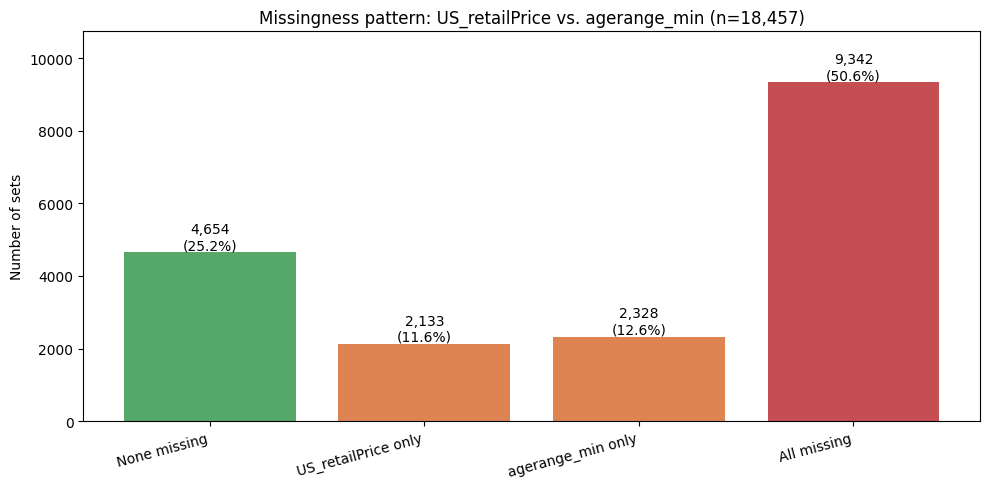

In [160]:
display_missing_values_cor(
    lego_df,
    lego_df['US_retailPrice'].isnull(),
    lego_df['agerange_min'].isnull()
)

##### **Minifigs and pieces**

- Correlation value: 0.4

The missingness of `pieces` and `minifigs` is asymmetric: nearly all rows
missing `pieces` (96%, 3,772 of 3,924) are also missing `minifigs`, but the
reverse is far less true. In other words, `pieces` rarely goes missing on
its own, while `minifigs` frequently does.

This suggests a shared underlying cause for a large subset of rows (likely a
common source or collection gap), but also means `minifigs` cannot be reliably
used as a predictor when imputing `pieces`, as for 96% of the rows that need
`pieces` imputed, `minifigs` is unavailable too. The reverse imputation
(using `pieces` to help impute `minifigs`) is comparatively more viable,
since `pieces` is present for most rows where `minifigs` is missing.

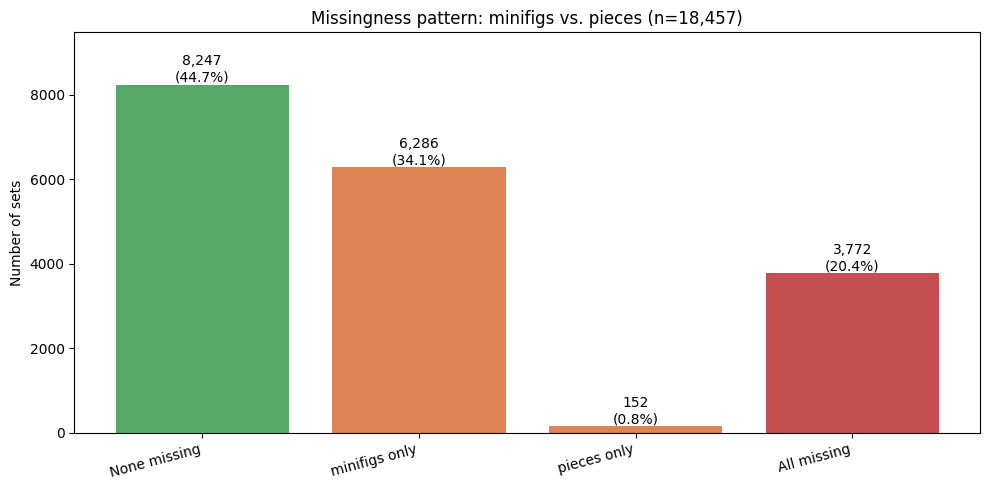

In [161]:
display_missing_values_cor(
    lego_df,
    lego_df['minifigs'].isnull(),
    lego_df['pieces'].isnull()
)

##### **agerange_min and pieces**

- Correlation value: 0.3

The missingness here is asymmetric, similar to the minifigs/pieces pair: of all rows missing `pieces` (3,924 total), 89.2% (3,499) are also missing `agerange_min`. But of all rows missing `agerange_min` (11,670 total), only 30.0% (3,499) are also missing `pieces`, the majority (8,171, or 70%) are missing `agerange_min` on its own.

So `pieces` rarely goes missing without `agerange_min` also being gone, but `agerange_min` is frequently missing independently. This reinforces the pattern seen with `minifigs`: `pieces` seems to sit at the "bottom" of a metadata hierarchy, when it's present, other fields tend to be present too, and when it's absent, several other fields are usually absent alongside it. Practically, this means `agerange_min` is a weak predictor for imputing `pieces` (unavailable for 89% of the rows that need it), while `pieces` remains a comparatively more available predictor for imputing `agerange_min`.

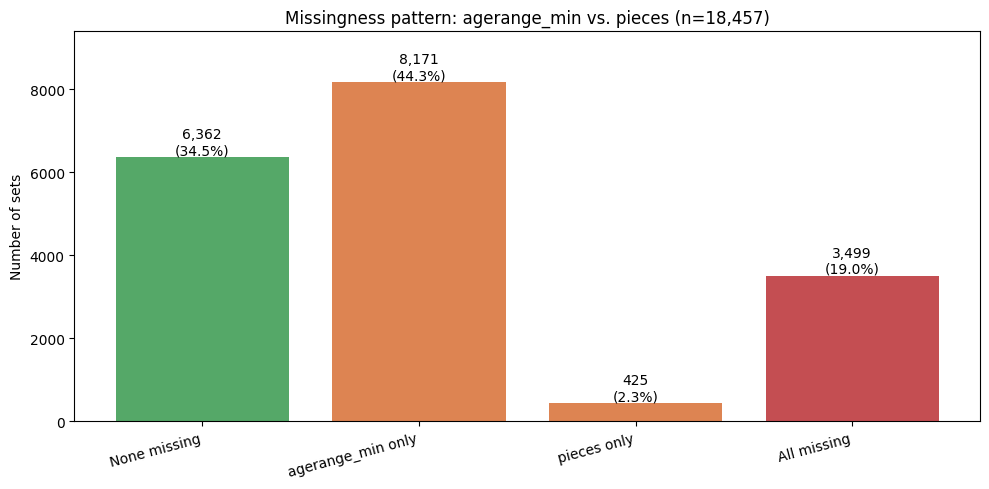

In [162]:
display_missing_values_cor(
    lego_df,
    lego_df['agerange_min'].isnull(),
    lego_df['pieces'].isnull()
)

##### **agerange_min and minifigs**

- Correlation value: 0.3

This pair is more symmetric than the previous two. Of all rows missing `agerange_min` (11,670 total), 65.8% (7,677) are also missing `minifigs`. Of all rows missing `minifigs` (10,058 total), 76.3% (7,677) are also missing `agerange_min`. Both directions show a strong overlap, unlike the pieces pairs where one variable was clearly "nested" inside the other's missingness.

This points toward a large shared cluster of roughly 7,677 sets (41.6% of the dataset) with thin metadata across multiple fields at once, rather than isolated column-specific gaps. Combined with the earlier pieces/minifigs and pieces/agerange_min findings, it's worth checking whether this ~7,700-row cluster is the *same* set of rows recurring across all three pairs. If so, this isn't three separate missingness problems, but one systematic gap affecting a specific, identifiable subgroup of the data (likely tied to `year` or `theme`, per the earlier discussion).

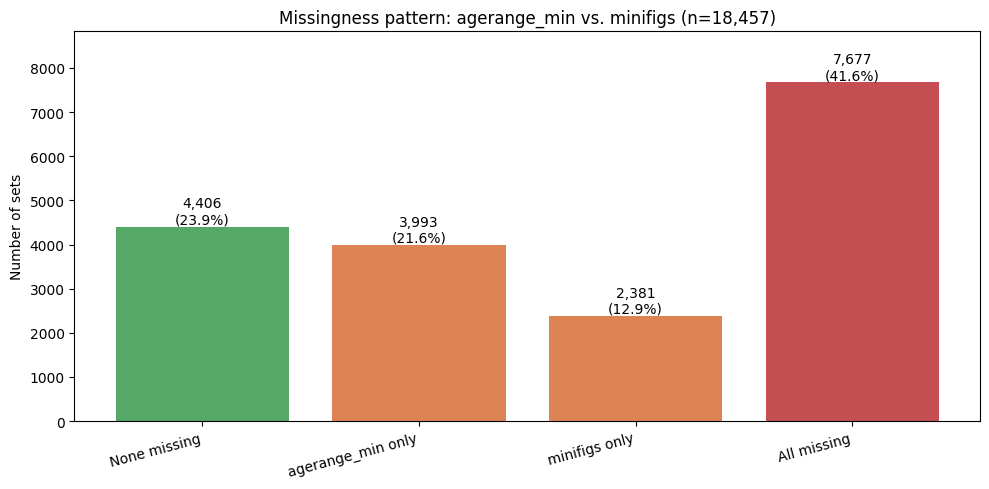

In [163]:
display_missing_values_cor(
    lego_df,
    lego_df['agerange_min'].isnull(),
    lego_df['minifigs'].isnull()
)

##### **pieces and subtheme**

- Correlation value: -0.2

Unlike the previous pairs, this relationship is negative, the two fields rarely go missing together. Only 0.8% (139) of rows are missing both, while the vast majority of missingness is split cleanly between `pieces only` (3,785, 20.5%) and `subtheme only` (3,417, 18.5%). If missingness were independent, we'd expect a noticeably higher "all missing" count given how large each individual missing group is; instead it's nearly the smallest category.

This suggests `pieces` and `subtheme` are captured through largely separate parts of the data collection process. When one is absent, the other is usually still present. Practically, this is good news: `subtheme` remains a mostly-available predictor for imputing `pieces` (and vice versa), unlike the `agerange_min`/`minifigs` situation where missingness clusters together and predictors vanish exactly when you need them most.

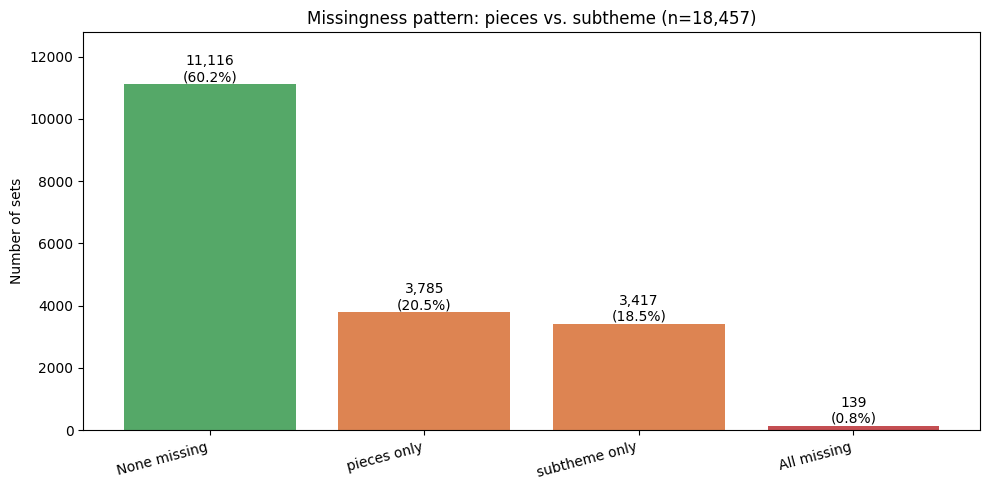

In [164]:
display_missing_values_cor(
    lego_df,
    lego_df['pieces'].isnull(),
    lego_df['subtheme'].isnull()
)

### **Summary: Missingness Analysis Conclusions**

Across all examined pairs, three distinct patterns emerge:

**1. Pure duplication - `imageURL` & `thumbnailURL` (correlation: 1.0)**
Perfectly linked missingness (5.5% of rows missing both, never one without the other). Confirms a shared source/pipeline. Probably not relevant to price prediction, safe to exclude from the imputation model.

**2. A shared "thin metadata" cluster - `agerange_min`, `minifigs`, `pieces`, and `US_retailPrice`**
These four fields show consistent positive co-missingness, but with an important asymmetry:
- `pieces` rarely goes missing alone: when it's gone, `minifigs` (96% of the time) and `agerange_min` (89% of the time) are usually gone too.
- `agerange_min` and `minifigs` are more mutually dependent (~ 66–76% overlap in both directions), pointing to a large shared subgroup (~7,677 rows, 41.6% of the dataset) with sparse metadata across several fields at once.
- `US_retailPrice` (the target) shares a moderate correlation (0.5) with `agerange_min`'s missingness, the strongest link to the target found in the matrix, and the one most directly relevant to the imputation task. 9,342 rows are missing both.

**Combined implication:** this isn't several independent column-specific gaps, it looks like one systematic collection issue affecting a specific, identifiable subgroup of sets (likely tied to `year` and/or `theme`, both of which are fully populated and worth cross-tabbing against this cluster next). For imputation, `pieces` and `minifigs` will frequently be unavailable together as predictors, so `theme`, `year`, and `subtheme` become the more reliable fallback features for that subgroup.

**3. Independent/complementary fields - `pieces` & `subtheme` (correlation: -0.2)**
Missing less often together than chance would predict (139 observed vs. ~756 expected under independence). These two are captured through largely separate parts of the data pipeline, meaning `subtheme` stays usable as a predictor even when `pieces` is missing, and vice versa.

---

### Practical takeaways for the price-imputation pipeline

- **Do not rely on `minifigs`/`pieces`/`agerange_min` as guaranteed predictors** for the large sparse-metadata subgroup, they tend to disappear together. `subtheme`, `theme`, and `year` (all fully populated or largely independent of the cluster) are the dependable fallback features.
- **Consider staged imputation**: impute `agerange_min` first (using theme/year/subtheme where pieces/minifigs are unavailable), then use the completed feature set to impute `US_retailPrice`.
- **Add a missingness indicator feature** (e.g., `thin_metadata_flag`) marking rows belonging to the sparse cluster, since the gap is systematic rather than random, this flag may itself carry predictive signal for the ANN.
- **Validate model performance separately on this subgroup** vs. the rest of the dataset once the model is built, since a single aggregate error metric could mask poor performance specifically on these harder-to-impute rows.
- **Exclude `imageURL`/`thumbnailURL`** from the feature set, irrelevant to price and functionally redundant with each other.

Next useful step: cross-tab the sparse-metadata cluster (~7,700-9,300 rows depending on the pair) against `year` and `theme` to determine whether this is concentrated in specific eras or product lines, which would confirm whether a subgroup-specific imputation strategy is warranted.

### **Exploring data distribution and outliers**

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def plot_distribution(df, col, bins=50, log_scale=False):
    """
    Plots a histogram + KDE for a numeric column, with skew/kurtosis stats.
    """
    data = df[col].dropna()

    skewness = data.skew()
    kurt = data.kurt()

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(data, bins=bins, kde=True, ax=ax, color='#4c72b0', log_scale=log_scale)

    ax.set_title(f'Distribution of {col}\n(n={len(data):,}, skew={skewness:.2f}, kurtosis={kurt:.2f})')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

    # reference line at mean and median to visualize skew direction
    mean_val = data.mean()
    median_val = data.median()
    ax.axvline(mean_val, color='#c44e52', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:,.2f}')
    ax.axvline(median_val, color='#55a868', linestyle='--', linewidth=1.5, label=f'Median: {median_val:,.2f}')
    ax.legend()

    plt.tight_layout()
    plt.savefig(f'distribution_{col}.png', dpi=150)
    plt.show()

    return {'skew': skewness, 'kurtosis': kurt, 'mean': mean_val, 'median': median_val}

In [166]:
lego_df.columns

Index(['set_id', 'name', 'year', 'theme', 'subtheme', 'themeGroup', 'category',
       'pieces', 'minifigs', 'agerange_min', 'US_retailPrice', 'bricksetURL',
       'thumbnailURL', 'imageURL'],
      dtype='object')

#### **US_retailPrice distribution**

Exploring the distribution of US_retailPrice we can see the data presents extreme skewness and a large presence of data allocated in the left tail (Kurtosis = 48.07).

That tells us there are far more sets of lower prices, and we need to first transform our target variable to use it on ANN.

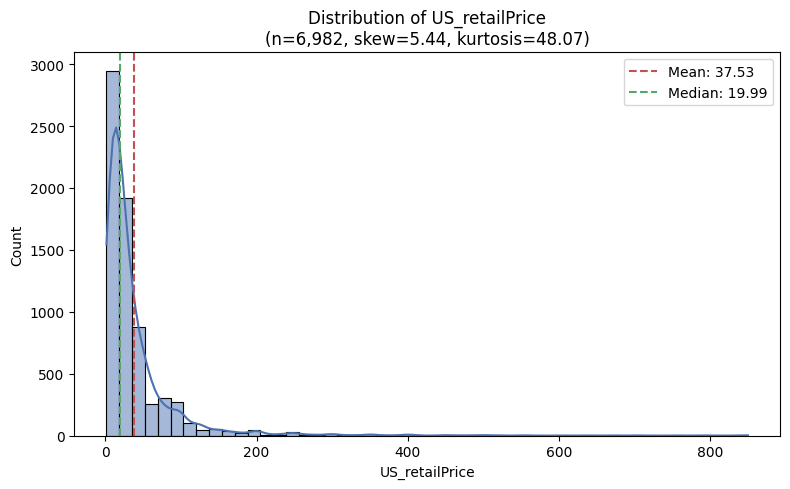

{'skew': np.float64(5.444356452399353), 'kurtosis': np.float64(48.07152024358233), 'mean': np.float64(37.53481667144085), 'median': 19.99}


In [167]:
stats_price = plot_distribution(lego_df, 'US_retailPrice')
print(stats_price)

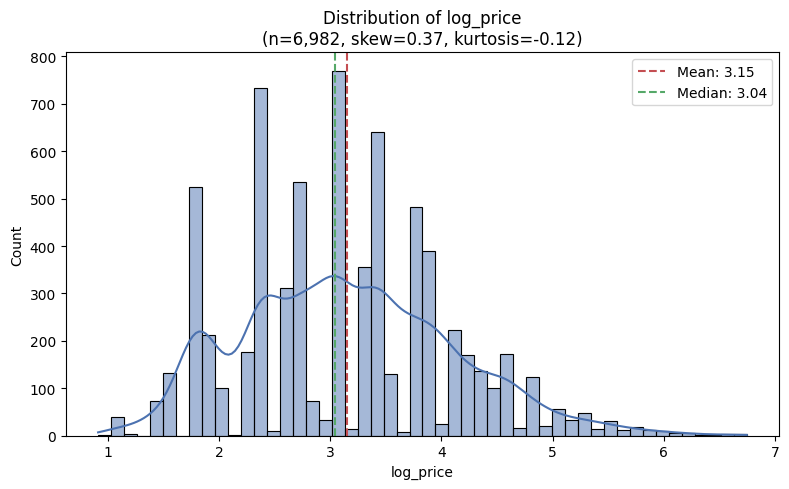

{'skew': np.float64(0.3689099387634133), 'kurtosis': np.float64(-0.1195644516015335), 'mean': np.float64(3.1488033107615236), 'median': 3.0440461338325413}


In [168]:
lego_df['log_price'] = np.log1p(lego_df['US_retailPrice'])
stats_log_price = plot_distribution(lego_df, 'log_price')
print(stats_log_price)

#### **Year distribution**

In here we see a much more balanced distribution, with ammount of lego sets released increasing along time as expected

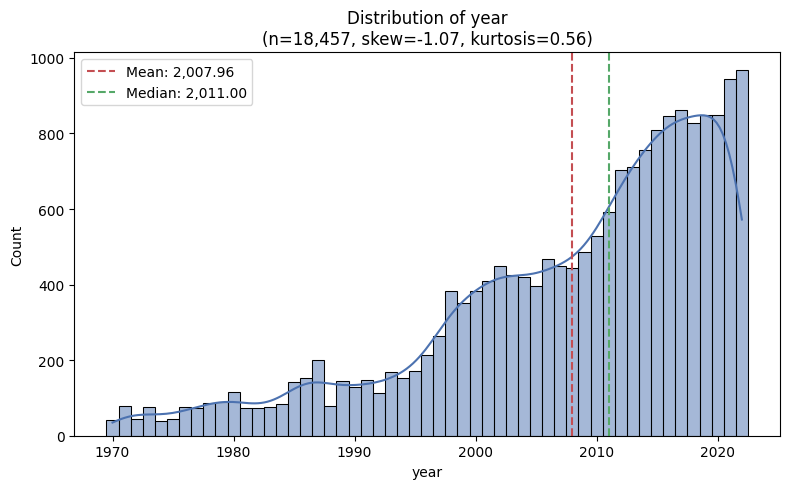

{'skew': np.float64(-1.0651805584249079), 'kurtosis': np.float64(0.5582654082255907), 'mean': np.float64(2007.960611150241), 'median': 2011.0}


In [169]:
bins = np.arange(lego_df['year'].min(), lego_df['year'].max() + 2) - 0.5
stats_year = plot_distribution(lego_df, 'year', bins)
print(stats_year)

#### **Pieces distribution**

This data is highly unbalanced, even more than US_priceRetail as we can se a large spike in its left tail. That means we can use a log distribution to help to balance out this extreme kurtosis.

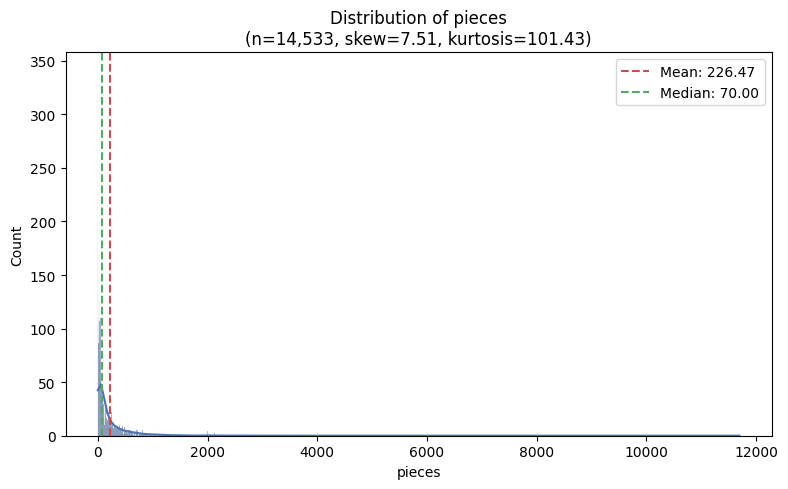

{'skew': np.float64(7.510224024263558), 'kurtosis': np.float64(101.43430985161702), 'mean': np.float64(226.47374939792198), 'median': 70.0}


In [170]:
bins = np.arange(lego_df['pieces'].min(), lego_df['pieces'].max() + 2) - 0.5
stats_pieces = plot_distribution(lego_df, 'pieces', bins=bins)
print(stats_pieces)

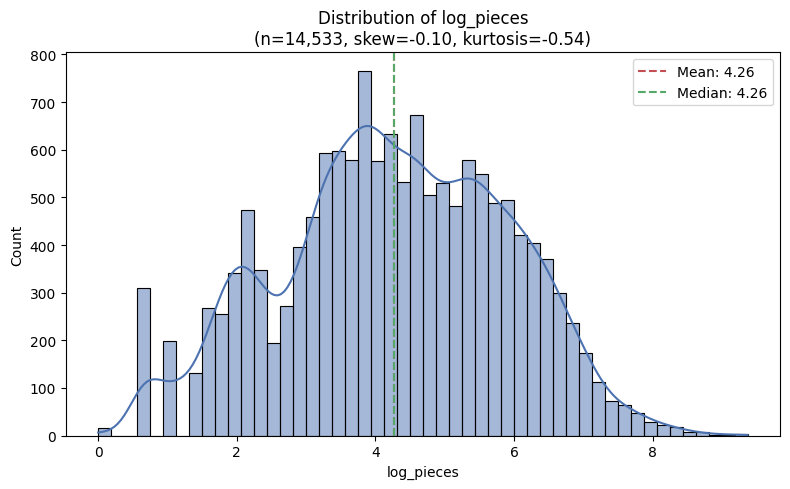

{'skew': np.float64(-0.103415993881326), 'kurtosis': np.float64(-0.5375090343884912), 'mean': np.float64(4.264841618851191), 'median': 4.2626798770413155}


In [171]:
lego_df['log_pieces'] = np.log1p(lego_df['pieces'])
stats_log_pieces = plot_distribution(lego_df, 'log_pieces')
print(stats_log_pieces)

#### **Minifigs distribution**

This data is highly unbalanced as we can se a large spike in its left tail. That means we can use a log distribution to help to balance out this extreme kurtosis.

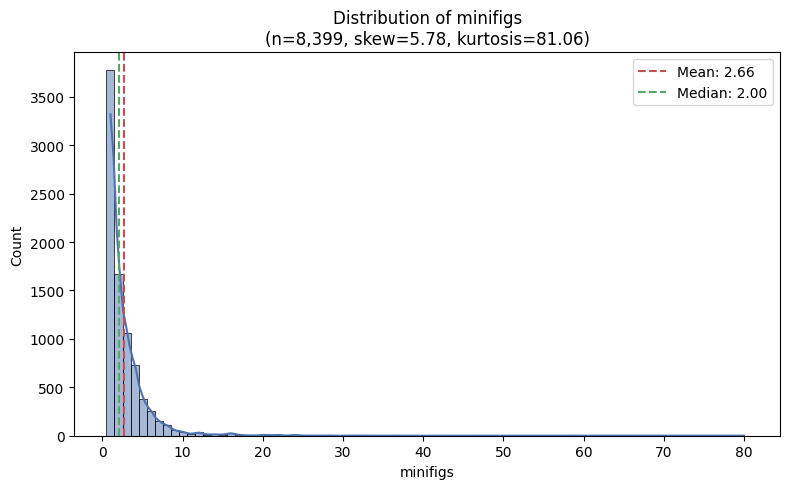

{'skew': np.float64(5.779555481310807), 'kurtosis': np.float64(81.05988987827182), 'mean': np.float64(2.6636504345755445), 'median': 2.0}


In [172]:
bins = np.arange(lego_df['minifigs'].min(), lego_df['minifigs'].max() + 2) - 0.5
stats_minifigs = plot_distribution(lego_df, 'minifigs', bins=bins)
print(stats_minifigs)

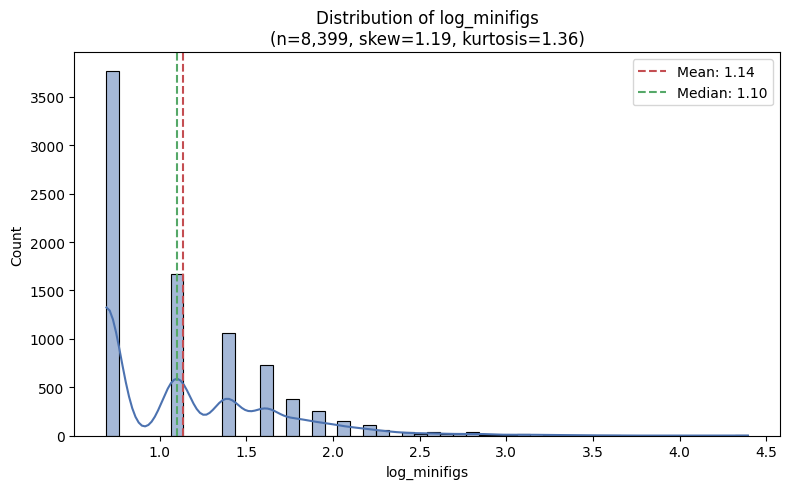

{'skew': np.float64(1.1888996354604406), 'kurtosis': np.float64(1.364997019387955), 'mean': np.float64(1.1361162372748637), 'median': 1.0986122886681096}


In [173]:
lego_df['log_minifigs'] = np.log1p(lego_df['minifigs'])
stats_log_minifigs = plot_distribution(lego_df, 'log_minifigs')
print(stats_log_minifigs)

After seeing the results of the log_transform we can say that, although the data is still not balanced in terms of skewness, we have reduced the severity of its effect, which might be the only possible result since we are dealing with low cardinal values.

#### **Category and Temporal Missingness Analysis**


We start by checking the value counts of the `category` column to understand the composition of the dataset.

This revealed the dataset isn't a uniform collection of "LEGO sets", it contains several product types: `Normal` (12,757, ~69%), `Gear` (2,832), `Other` (1,094), `Book` (631), `Collection` (578), `Extended` (501), and `Random` (64). `Normal` dominates and represents the standard buildable-set population most relevant to price prediction.

In [174]:
lego_df['category'].value_counts()


,count
category,
Normal,12757
Gear,2832
Other,1094
Book,631
Collection,578
Extended,501
Random,64


Next, we can group missingness of `pieces` and `US_retailPrice` by `category` to check whether missing values were evenly spread or concentrated in specific product types.

This showed `pieces` is missing almost entirely within `Gear` (100%) and heavily within `Book`/`Random`/`Other` (77–89%) categories where a piece count structurally doesn't apply (e.g., chess sets, keychains, books). `Normal` had the lowest missing-pieces rate (1.7%), confirming it's the most complete category for that field. Meanwhile, `US_retailPrice` was missing across the board, but notably still at 59.5% even within `Normal`, the category we'd expect to be most complete.

In [175]:
lego_df.groupby('category')['pieces'].apply(lambda x: x.isnull().mean()).sort_values(ascending=False)

,pieces
category,
Gear,1.000000
Book,0.889065
Random,0.765625
Other,0.136197
Extended,0.115768
Collection,0.102076
Normal,0.016932


In [176]:
lego_df.groupby('category')['US_retailPrice'].apply(lambda x: x.isnull().mean()).sort_values(ascending=False)

,US_retailPrice
category,
Other,0.989031
Book,0.971474
Collection,0.944637
Random,0.859375
Extended,0.760479
Normal,0.594889
Gear,0.426907


Because the `Normal` category still showed high price-missingness, we should look further into whether that gap was random or concentrated in time:

This revealed a sharp structural break: price is **almost entirely missing (~100%) for sets before 2005**, transitions through 2005–2006, then stabilizes at a **much lower, consistent missing rate (~20–36%) from 2007 onward**.

In [177]:
normal_df = lego_df[lego_df['category'] == 'Normal']
normal_df.groupby('year')['US_retailPrice'].apply(lambda x: x.isnull().mean())

,US_retailPrice
year,
1970,1.000000
1971,1.000000
1972,1.000000
1973,1.000000
1974,1.000000
1975,1.000000
1976,1.000000
1977,1.000000
1978,1.000000


The `category` breakdown explained why `pieces` goes missing for non-buildable product types (a conceptual mismatch, not a data gap), while the year-based breakdown explained why`US_retailPrice` is missing even for standard sets, a historical data-collection boundary around 2005, not random or scattered incompleteness. This means the two missingness problems have different root causes and need different treatment: `pieces` missingness is largely category-driven (exclude/handle non-Normal categories separately), while `price` missingness is era-driven (pre-2005 likely unimputable via modeling and better suited to real-data lookup or exclusion; post-2007 is a standard imputation problem).

Bellow we can look into some larger samples of each of the categories analyzed:

In [178]:
display(lego_df[lego_df['category'] == 'Gear'][['set_id', 'name', 'pieces', 'US_retailPrice']].sample(20))

,set_id,name,pieces,US_retailPrice
13871,5005320-1,Batman Prestige Costume,NaN,69.99
8668,2855044-1,Cavalry Colonel,NaN,NaN
7654,852395-1,Writing Pad,NaN,NaN
4155,5724-1,LEGO Stunt Rally,NaN,NaN
7185,852008-1,Knight Hero Armour,NaN,NaN
11333,5003024-1,Lucy Wyldstyle Link Watch,NaN,24.99
7629,852314-1,Batman (Grey Suit) Key Chain,NaN,3.99
7702,K810022-1,Duplo 3-Piece Bedding Set Pink - Junior,NaN,NaN
5121,KC028-1,C-3PO,NaN,NaN
17192,854112-1,Daisy Duck Key Chain,NaN,5.99


In [179]:
display(lego_df[lego_df['category'] == 'Book'][['set_id', 'name', 'pieces']].sample(20))

,set_id,name,pieces
1921,BK13FAL1990-1,BRICK KICKS Fall 1990,NaN
15678,ISBN9781624149108-1,Amazing LEGO Creations from Space with Bricks ...,NaN
9969,BRICKJOURNAL017-1,BrickJournal Issue 17,NaN
9294,ISBN9780756686970-1,LEGO Star Wars: Character Encyclopedia,4.0
13119,ISBN9781440246999-1,The Ultimate Guide to Collectible Minifigures,NaN
7695,ISBN9781593271886-1,LEGO MINDSTORMS NXT One-Kit Wonders,NaN
10717,ISBN9781626361188-1,A Million Little Bricks: The Unofficial Illust...,NaN
13976,ISBN9780760352656-1,How to Build Brick Cars: Detailed LEGO Designs...,NaN
13945,BLOCKS036-1,Blocks magazine issue 36,NaN
2180,BK22WIN1992-1,BRICK KICKS Winter 1992,NaN


In [180]:
display(lego_df[lego_df['category'] == 'Random'][['set_id', 'name', 'pieces', 'US_retailPrice']].sample(15))

,set_id,name,pieces,US_retailPrice
16035,71026-0,LEGO Minifigures - DC Super Heroes Series {Ran...,NaN,NaN
17813,66733-1,LEGO Minifigures - Series 24 {Box of 6 random...,NaN,29.94
9543,8909-0,LEGO Minifigures - Team GB {Random bag},NaN,NaN
16823,43108-0,Bandmates Series 2 {Random box},NaN,NaN
13237,30324-0,My Town {Random Bag},NaN,NaN
10402,71001-0,LEGO Minifigures Series 10 {Random bag},NaN,NaN
14385,71020-0,LEGO Minifigures - The LEGO Batman Movie Serie...,NaN,NaN
8416,8683-0,LEGO Minifigures - Series 1 {Random bag},NaN,1.99
14285,41775-0,Blind Bags Series 1 {Random bag},14.0,NaN
9486,8827-0,LEGO Minifigures - Series 6 {Random bag},NaN,NaN


#### **Agerange_min distribution**

In this case, although we can see some skewness and kurtosis showing up, we will not move foward with any transformation, as agerange is a rather categorical/ordinal value it should add more value to our ANN this way.

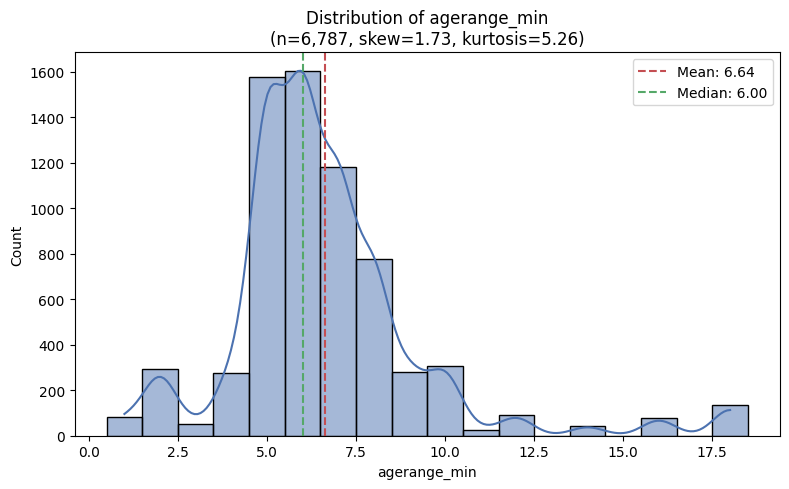

{'skew': np.float64(1.7308305686208032), 'kurtosis': np.float64(5.255051210407437), 'mean': np.float64(6.637542360394873), 'median': 6.0}


In [181]:
bins = np.arange(lego_df['agerange_min'].min(), lego_df['agerange_min'].max() + 2) - 0.5
stats_agerange = plot_distribution(lego_df, 'agerange_min', bins=bins)
print(stats_agerange)

#### **Theme, themeGroup and subtheme distribution**

After scoping the dataset to the `Normal` category, we examined the three theme-related fields to decide how each should be encoded for modeling.

**`theme`** (147 unique values, 0 missing within `Normal`)
`theme` is a high-cardinality categorical field, and a large portion of it is sparsely populated: 35 of the 147 themes (24%) have fewer than 10 sets, several with as few as 1–2 (e.g., `LEGO Universe`, `Boost`, `Stranger Things`). One-hot encoding these as-is would create many near-empty columns the model could not learn from reliably, and risks unseen-category issues between train and test splits. To address this, themes with fewer than 10 sets were grouped into a single `"Other"` bucket (`theme_grouped`), reducing the effective category count while preserving the signal from well-represented themes.

**`themeGroup`** (16 unique values, 1 missing)
`themeGroup` is a much lower-cardinality rollup of `theme`. Checking the mapping between the two confirmed it is *not* redundant: groups like `Licensed` span 42 distinct themes and `Action/Adventure` spans 22, showing themeGroup captures a genuinely coarser level of structure rather than mirroring theme one-to-one. Because of this, and because it offers a fallback signal for sets whose specific theme was bucketed into `"Other"`, `themeGroup` was kept as a separate encoded feature alongside `theme`.

**`subtheme`** (669 unique values, 27% missing within `Normal`)
`subtheme` combines very high cardinality with substantial missingness, and several of its top values (`Promotional`, `Accessories`, `Miscellaneous`) still resemble non-standard or non-buildable labels even within the `Normal` category. Given the added complexity of imputing a categorical field with this many levels for over a quarter of rows, and the limited expected marginal benefit once `theme` and `themeGroup` are already included, `subtheme` was dropped from the modeling feature set.

**Resulting plan:**
| Feature | Decision |
|---|---|
| `theme` | Rare themes (<10 sets) grouped into `"Other"`, then one-hot encoded |
| `themeGroup` | Kept as-is, one-hot encoded |
| `subtheme` | Dropped |

In [182]:
normal_df = lego_df[lego_df['category'] == 'Normal']

for col in ['theme', 'themeGroup', 'subtheme']:
    print(f"--- {col} ---")
    print(f"Unique values: {normal_df[col].nunique()}")
    print(f"Missing: {normal_df[col].isnull().sum()}")
    print(normal_df[col].value_counts().head(10))
    print()

--- theme ---
Unique values: 147
Missing: 0
theme
Duplo                      1220
Star Wars                   651
Collectable Minifigures     639
Town                        628
City                        619
Creator                     460
Technic                     456
Basic                       408
Service Packs               385
Friends                     367
Name: count, dtype: int64

--- themeGroup ---
Unique values: 16
Missing: 1
themeGroup
Licensed            2009
Modern day          2003
Miscellaneous       1741
Pre-school          1478
Action/Adventure    1104
Basic                830
Model making         647
Technical            565
Educational          460
Historical           439
Name: count, dtype: int64

--- subtheme ---
Unique values: 669
Missing: 3457
subtheme
Promotional      211
3 in 1           205
Trains           150
Classic          144
Seasonal         125
Duplo            122
Miscellaneous    116
Police           116
Technic          113
Accessories      11

In [183]:
# How many themes are "rare" (risk for one-hot encoding)?
print((normal_df['theme'].value_counts() < 10).sum())
print(normal_df['theme'].value_counts().tail(20))

# Does themeGroup add signal beyond theme, or is it redundant?
print(normal_df.groupby('themeGroup')['theme'].nunique().sort_values(ascending=False))

35
theme
Ben 10: Alien Force          6
Prince of Persia             6
Discovery                    6
Scooby-Doo                   6
The Angry Birds Movie        6
Mickey Mouse                 5
Dino 2010                    5
Dino Attack                  5
FORMA                        4
Spybotics                    4
Avatar                       4
Fusion                       4
Avatar The Last Airbender    2
Ghostbusters                 2
Life of George               2
The Simpsons                 2
The Powerpuff Girls          2
LEGO Universe                1
Boost                        1
Stranger Things              1
Name: count, dtype: int64
themeGroup
Licensed            42
Action/Adventure    22
Miscellaneous       16
Modern day           9
Pre-school           7
Basic                7
Historical           6
Model making         6
Vintage              6
Technical            6
Junior               5
Girls                3
Constraction         3
Educational          3
Racing      

In [184]:
model_df = lego_df[(lego_df['category'] == 'Normal') & (lego_df['year'] >= 2007)].copy()

theme_counts = model_df['theme'].value_counts()
rare_themes = theme_counts[theme_counts < 10].index

model_df['theme_grouped'] = model_df['theme'].where(~model_df['theme'].isin(rare_themes), 'Other')
print(model_df['theme_grouped'].nunique())

75


#### **Outliers**

Checking the distribution of prices accross the model_df we can see this portion has a ballanced spread, so it will be of value to our model

In [185]:
display(model_df.nlargest(10, 'US_retailPrice')[['name', 'theme', 'pieces', 'US_retailPrice']])
display(model_df.nsmallest(10, 'US_retailPrice')[['name', 'theme', 'pieces', 'US_retailPrice']])

,name,theme,pieces,US_retailPrice
13651,Millennium Falcon,Star Wars,7541.0,849.99
17046,AT-AT,Star Wars,6785.0,849.99
10584,Identity and Landscape Kit,Serious Play,2631.0,789.99
10585,Connections Kit,Serious Play,2455.0,754.99
15267,Imperial Star Destroyer,Star Wars,4784.0,699.99
16559,Titanic,Icons,9090.0,679.99
17500,Eiffel Tower,Icons,10001.0,629.99
17934,The Razor Crest,Star Wars,6187.0,599.99
15703,Colosseum,Icons,9036.0,549.99
17962,Hulkbuster,Marvel Super Heroes,4049.0,549.99


,name,theme,pieces,US_retailPrice
7041,Squid Ammo,Bionicle,7.0,1.99
8417,Tribal Hunter,Collectable Minifigures,9.0,1.99
8418,Cheerleader,Collectable Minifigures,7.0,1.99
8419,Caveman,Collectable Minifigures,6.0,1.99
8420,Circus Clown,Collectable Minifigures,6.0,1.99
8421,Zombie,Collectable Minifigures,6.0,1.99
8422,Skater,Collectable Minifigures,8.0,1.99
8423,Robot,Collectable Minifigures,6.0,1.99
8424,Demolition Dummy,Collectable Minifigures,6.0,1.99
8425,Magician,Collectable Minifigures,6.0,1.99


In here, the less than 1% outliers detected by IQR means we are ready to move on to analyzing correlation accross features

In [186]:
for col in ['log_price', 'log_pieces', 'log_minifigs']:
    q1, q3 = model_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_outliers = ((model_df[col] < lower) | (model_df[col] > upper)).sum()
    print(f"{col}: {n_outliers} outliers ({n_outliers/len(model_df):.1%})")

log_price: 32 outliers (0.5%)
log_pieces: 3 outliers (0.0%)
log_minifigs: 21 outliers (0.3%)


#### **The strong correlation between Prices and Pieces:**

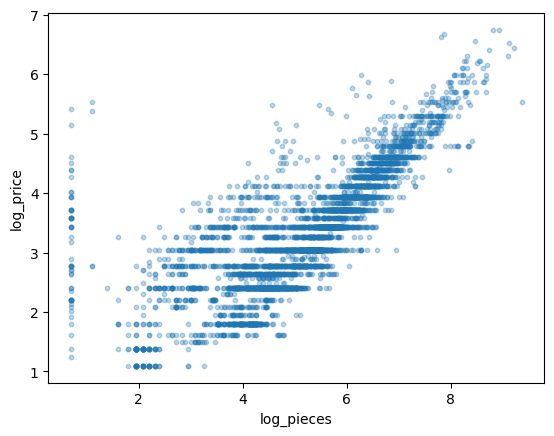

In [187]:
plt.scatter(model_df['log_pieces'], model_df['log_price'], alpha=0.3, s=10)
plt.xlabel('log_pieces'); plt.ylabel('log_price')
plt.show()

### **Correlation analysis**

We can analyze that the numerical features log_pieces, log_minifigs and agerange_min are very valuable to our model and even though small, year still contributes towards our prediction

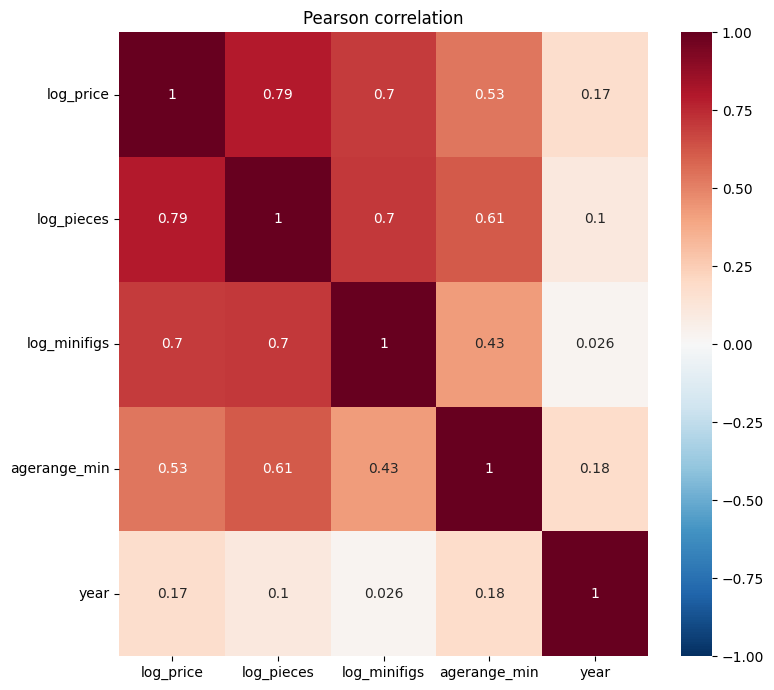

In [188]:
numeric_cols = ['log_price', 'log_pieces', 'log_minifigs', 'agerange_min', 'year']

plt.figure(figsize=(8, 7))
sns.heatmap(model_df[numeric_cols].corr(method='pearson'), annot=True, cmap='RdBu_r', vmin=-1, vmax=1)
plt.yticks(rotation=0)
plt.title('Pearson correlation')
plt.tight_layout()
plt.savefig('pearson_corr.png', dpi=150)
plt.show()

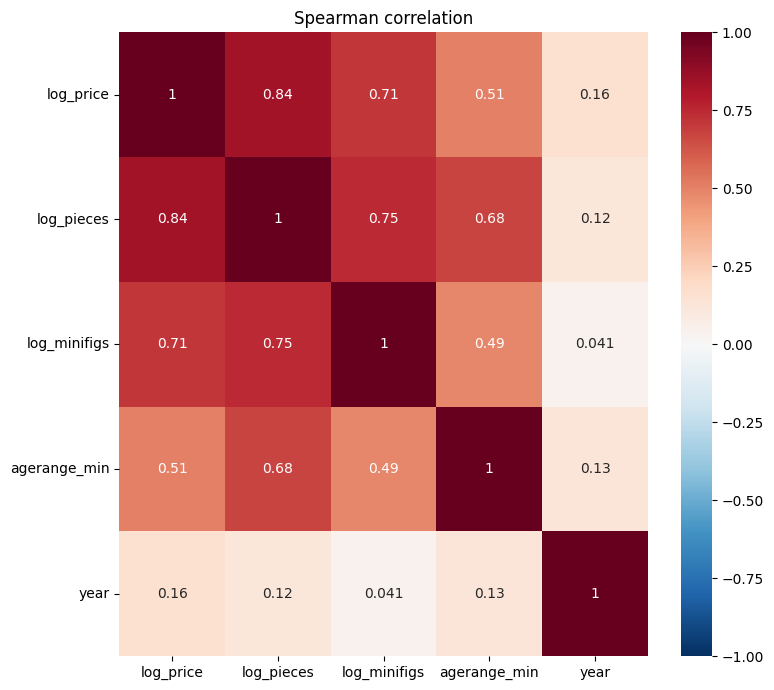

In [189]:
plt.figure(figsize=(8, 7))
sns.heatmap(model_df[numeric_cols].corr(method='spearman'), annot=True, cmap='RdBu_r', vmin=-1, vmax=1)
plt.yticks(rotation=0)
plt.title('Spearman correlation')
plt.tight_layout()
plt.savefig('spearman_corr.png', dpi=150)
plt.show()

**`theme` (and `theme_grouped`)**
Boxplots of `log_price` by theme showed clear, meaningful separation across categories: median price ranged from ~ 4.9 (Education) down to ~ 1.3 (Collectable Minifigures) in log-space, confirming theme carries real, independent signal beyond what `pieces`, `minifigs`, and `agerange_min` already explain. During this analysis, the `Education` theme was found to mix two structurally different product types, full buildable robotics kits (e.g., SPIKE Prime) and single electronic components (sensors, motors) priced by technology rather than piece count with an 85% missing-price rate, well above the dataset's baseline. Given its small size (187 of 6,887 rows, 2.7%) and low usable signal (~28 priced rows), `Education` was excluded from the modeling dataset, following the same reasoning used for category-level exclusions (Gear, Book, Random).

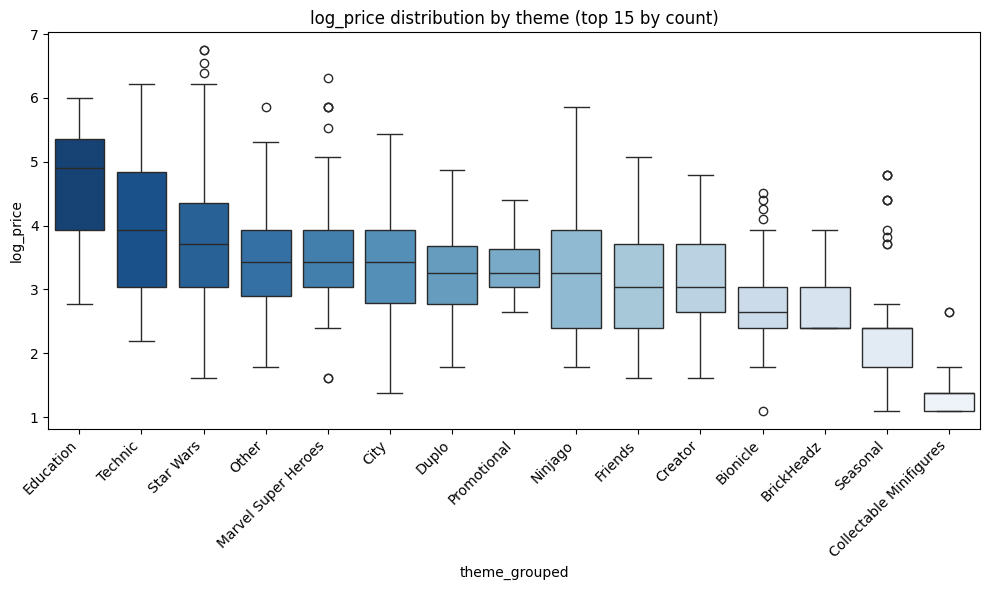

In [190]:
top_themes = model_df['theme_grouped'].value_counts().head(15).index
subset = model_df[model_df['theme_grouped'].isin(top_themes)]

order = subset.groupby('theme_grouped')['log_price'].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.boxplot(data=subset, x='theme_grouped', y='log_price', hue='theme_grouped', order=order, hue_order=order, palette='Blues_r', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('log_price distribution by theme (top 15 by count)')
plt.tight_layout()
plt.savefig('price_by_theme.png', dpi=150)
plt.show()

In [191]:
edu_df = model_df[model_df['theme_grouped'] == 'Education']
print(len(edu_df))
print(edu_df['US_retailPrice'].isnull().mean())

187
0.8502673796791443


In [192]:
model_df = model_df[model_df['theme_grouped'] != 'Education'].copy()
print(len(model_df))

6700




**`themeGroup`**
Confirmed non-redundant with `theme`: each of the 16 groups maps to multiple distinct themes (e.g., `Licensed` spans 42 themes, `Action/Adventure` spans 22), meaning `themeGroup` captures a genuinely coarser layer of structure rather than duplicating `theme`. It was kept as a separate encoded feature, providing a useful fallback signal for rows whose specific theme was bucketed into `"Other"`.

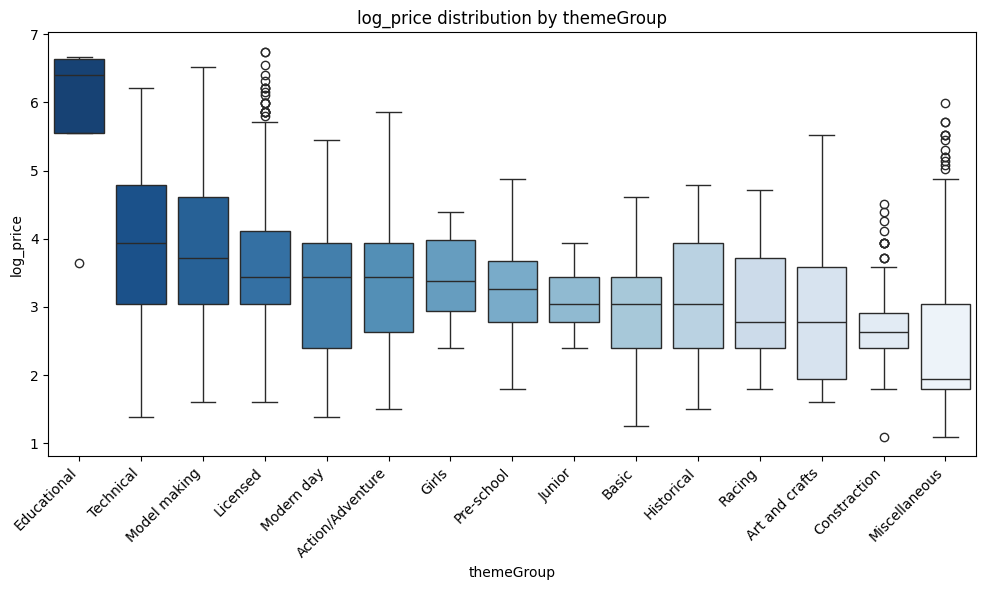

In [193]:
order = model_df.groupby('themeGroup')['log_price'].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.boxplot(data=model_df, x='themeGroup', y='log_price', hue='themeGroup', order=order, hue_order=order, palette='Blues_r', legend=False)
plt.xticks(rotation=45, ha='right')
plt.title('log_price distribution by themeGroup')
plt.tight_layout()
plt.savefig('price_by_themegroup.png', dpi=150)
plt.show()

**Overall conclusion:**
Categorical theme-related features contribute real, non-redundant predictive signal for `US_retailPrice`, justifying their inclusion in the model, but this analysis also surfaced a second, finer-grained exclusion (`Education`) beyond the earlier category-level filtering, reinforcing that missingness and pricing-logic inconsistencies exist at multiple levels of granularity in this dataset, not just at the top-level `category` split.

## **Rechecking missigness accross the model_df**

In [194]:
missing_summary = model_df[['pieces', 'minifigs', 'agerange_min', 'US_retailPrice']].isnull().sum()
missing_pct = model_df[['pieces', 'minifigs', 'agerange_min', 'US_retailPrice']].isnull().mean() * 100

pd.DataFrame({'missing_count': missing_summary, 'missing_pct': missing_pct.round(1)})

,missing_count,missing_pct
pieces,122,1.8
minifigs,2108,31.5
agerange_min,1256,18.7
US_retailPrice,1740,26.0


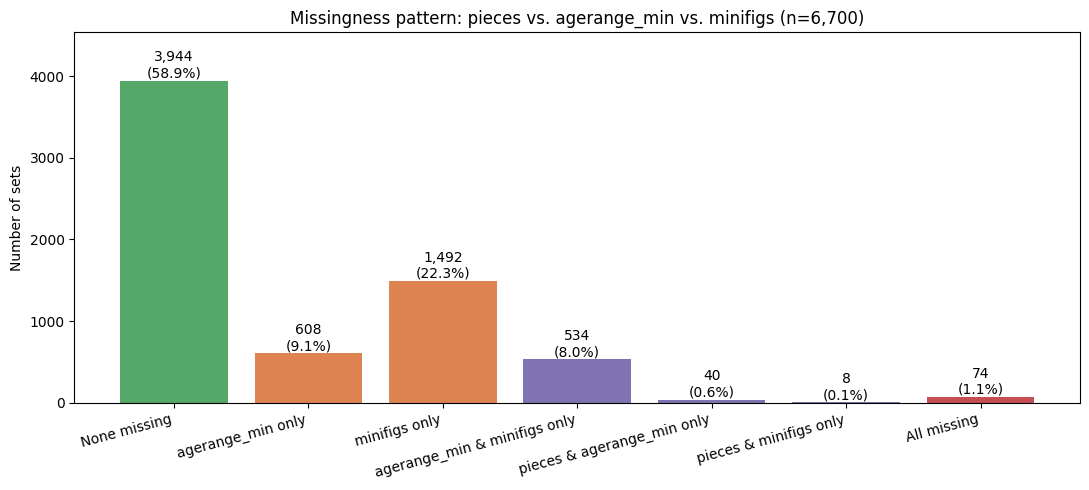

In [195]:
display_missing_values_cor(model_df, model_df['pieces'].isnull(), model_df['agerange_min'].isnull(), model_df['minifigs'].isnull())

## **Building the dataset**

In this step, we will build our dataset, using an inputter strategy to fill missing values

#### Buil

In [196]:
known_price_df = model_df[model_df['US_retailPrice'].notnull()].copy()
missing_price_df = model_df[model_df['US_retailPrice'].isnull()].copy()

known_price_df['log_price'] = np.log1p(known_price_df['US_retailPrice'])

print(f"Known price (train/test pool): {len(known_price_df)}")
print(f"Missing price (to predict later): {len(missing_price_df)}")

Known price (train/test pool): 4960
Missing price (to predict later): 1740


Before any preprocessing or modeling, `known_price_df` (the 4,960 rows with a recorded `US_retailPrice`) is split into three independent sets:

- **Train** (~70%): used to fit the model and, later, the imputers/scalers/encoders.
- **Validation** (~15%): used to check performance while tuning (e.g., model architecture), without touching the test set.
- **Test** (~15%): held out completely until final evaluation, giving an unbiased estimate of real-world performance.

The split is done in two steps: first separating `test` from everything else, then splitting the remainder into `train` and `val`. This three-way split (rather than a simple train/test split) avoids the risk of indirectly overfitting to the test set through repeated tuning decisions. `random_state=42` is fixed for reproducibility across all subsequent steps.

Only `known_price_df` is used here, `missing_price_df` (the 1,740 rows without a price) is intentionally excluded from this process, since it will only be used for final prediction once the model is trained.

In [197]:
from sklearn.model_selection import train_test_split

numeric_features = ['pieces', 'minifigs', 'agerange_min', 'year']
categorical_features = ['theme_grouped', 'themeGroup']
target = 'log_price'

X = known_price_df[numeric_features + categorical_features]
y = known_price_df[target]

# first split off test set (held out until the very end)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# then split remaining into train/val
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 3473, Val: 743, Test: 744


### Preprocessing Pipeline: Imputation, Transformation, Scaling & Encoding

This builds a single `ColumnTransformer` that applies a different preprocessing path to each group of features, so that missing values, skewed distributions, and categorical variables are all handled appropriately in one consistent step:

- **`log_pipeline`** (`pieces`, `minifigs`): missing values are imputed using `IterativeImputer`, then log-transformed to correct the strong right skew identified during EDA, then standard-scaled. Imputed values are clipped to a minimum of 0 before the log step, since the imputer can occasionally produce small negative estimates that are invalid for a piece/minifig count.
- **`plain_pipeline`** (`agerange_min`, `year`): imputed the same way, then standard-scaled.
- **`categorical_pipeline`** (`theme_grouped`, `themeGroup`): missing values filled with the most frequent category, then one-hot encoded. `handle_unknown='ignore'` ensures the pipeline doesn't break if a category appears in validation/test data that wasn't seen during training.

All three paths are combined into one `preprocessor`, which can be fit once and reused consistently across train, validation, test, and the final missing-price prediction set.

**Fitting and applying the pipeline:**
`preprocessor.fit_transform(X_train)` fits every imputer, scaler, and encoder using *only* the training data, then transforms it, this is what determines the imputation relationships, scaling parameters, and known categories. `preprocessor.transform(X_val)` and `preprocessor.transform(X_test)` then apply that same, already-learned transformation to the validation and test sets, without re-fitting on them. This ordering prevents any information from validation/test rows leaking into how the training data was processed.

The resulting transformed arrays expand from 6 original columns (4 numeric + 2 categorical) to 93 columns, reflecting the one-hot encoding of `theme_grouped` (~74 categories) and `themeGroup` ( ~16 categories).

In [198]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
import numpy as np

log_features = ['pieces', 'minifigs']
plain_numeric_features = ['agerange_min', 'year']
categorical_features = ['theme_grouped', 'themeGroup']

def safe_log1p(X):
    return np.log1p(np.clip(X, a_min=0, a_max=None))

log_pipeline = Pipeline([
    ('imputer', IterativeImputer(random_state=42, max_iter=10)),
    ('log', FunctionTransformer(safe_log1p, validate=True)),
    ('scaler', StandardScaler())
])

plain_pipeline = Pipeline([
    ('imputer', IterativeImputer(random_state=42, max_iter=10)),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('log_num', log_pipeline, log_features),
    ('plain_num', plain_pipeline, plain_numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [199]:
X_train_transformed = preprocessor.fit_transform(X_train)
print(X_train_transformed.shape)

(3473, 93)


In [200]:
X_val_transformed = preprocessor.transform(X_val)
X_test_transformed = preprocessor.transform(X_test)

print(X_val_transformed.shape, X_test_transformed.shape)

(743, 93) (744, 93)


## **Training the ANN**

An `MLPRegressor` (scikit-learn's implementation of a feedforward artificial neural network) is trained on the preprocessed training data to predict `log_price`. The architecture uses two hidden layers (64 and 32 neurons) with ReLU activation and the Adam optimizer. `early_stopping=True` reserves a portion of the training data internally to monitor performance and halts training once no improvement is seen for 20 consecutive iterations (`n_iter_no_change=20`), helping prevent overfitting without manual intervention. `random_state=42` is fixed for reproducibility.

In [201]:
from sklearn.neural_network import MLPRegressor

ann = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    n_iter_no_change=20
)

ann.fit(X_train_transformed, y_train)

MLPRegressor(early_stopping=True, hidden_layer_sizes=(64, 32), max_iter=1000,
             n_iter_no_change=20, random_state=42)

## **Validation Results**

The trained model is evaluated on the held-out validation set, both in log-space (the scale the model was actually trained on) and back-transformed to real dollar values (via `np.expm1`) for a more interpretable read on performance:

| Metric | Log scale | Dollar scale |
|---|---:|---:|
| RMSE | 0.234 | USD 14.60 |
| MAE | 0.170 | USD 7.23 |
| R² | 0.938 | — |

The model explains roughly 94% of the variance in price on unseen data, and on average predicts within about $7 of the true retail price. The gap between RMSE and MAE (roughly 2x) suggests a small right-skew in prediction error, likely driven by higher-priced, high-piece-count sets, where absolute dollar variance is naturally larger, consistent with patterns observed during EDA. Overall, this indicates the model has learned a strong, generalizable relationship between a set's features (pieces, minifigs, age range, theme) and its retail price, validating the feature engineering and dataset scoping decisions made earlier in the pipeline.

In [202]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_val_pred = ann.predict(X_val_transformed)

print("Val RMSE (log):", np.sqrt(mean_squared_error(y_val, y_val_pred)))
print("Val MAE (log):", mean_absolute_error(y_val, y_val_pred))
print("Val R²:", r2_score(y_val, y_val_pred))

y_val_real = np.expm1(y_val)
y_val_pred_real = np.expm1(y_val_pred)

print("\nVal RMSE ($):", np.sqrt(mean_squared_error(y_val_real, y_val_pred_real)))
print("Val MAE ($):", mean_absolute_error(y_val_real, y_val_pred_real))

Val RMSE (log): 0.2343455398405215
Val MAE (log): 0.16973135038683904
Val R²: 0.9375353978850904

Val RMSE ($): 14.60061405382983
Val MAE ($): 7.230149521724702


### Test Set Evaluation

As a final, unbiased check, the model is evaluated once on the held-out test set, data that played no role in training or in any tuning decisions up to this point:

| Metric | Validation | Test |
|---:|---:|---:|
| R² | 0.938 | 0.948 |
| MAE (USD) | USD 7.23 | USD 7.36 |
| RMSE (USD) | USD 14.60 | USD 15.22 |

Test performance is essentially in line with validation. This close agreement confirms the model generalizes well and isn't overfit to the validation set, giving confidence that the reported metrics reflect genuine predictive performance rather than an artifact of the split. The final model explains roughly 95% of the variance in LEGO set retail price, with an average prediction error of about $7.36 on data it had never seen in any capacity.

In [203]:
y_test_pred = ann.predict(X_test_transformed)

print("Test RMSE (log):", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("Test MAE (log):", mean_absolute_error(y_test, y_test_pred))
print("Test R²:", r2_score(y_test, y_test_pred))

y_test_real = np.expm1(y_test)
y_test_pred_real = np.expm1(y_test_pred)

print("\nTest RMSE ($):", np.sqrt(mean_squared_error(y_test_real, y_test_pred_real)))
print("Test MAE ($):", mean_absolute_error(y_test_real, y_test_pred_real))

Test RMSE (log): 0.21887425796934215
Test MAE (log): 0.16260801093244653
Test R²: 0.94782568257803

Test RMSE ($): 15.222328380885964
Test MAE ($): 7.360975657717666


## **Predicting the Missing Prices**

With the model trained and validated, the fitted `preprocessor` and `ann` are applied to `missing_price_df`, containing the 1,740 rows that never had a recorded `US_retailPrice`. The same feature columns used in training (`numeric_features` + `categorical_features`) are transformed using the *already-fitted* pipeline (`.transform()`, not `.fit_transform()`), ensuring these rows are processed identically to, but without influencing, the training data. The model's output (`log_price_pred`) is back-transformed with `np.expm1` to recover real dollar values, producing the final `predicted_US_retailPrice` column.

In [204]:
X_missing = missing_price_df[numeric_features + categorical_features]
X_missing_transformed = preprocessor.transform(X_missing)

log_price_pred = ann.predict(X_missing_transformed)
missing_price_df['predicted_US_retailPrice'] = np.expm1(log_price_pred)

missing_price_df[['name', 'theme', 'pieces', 'predicted_US_retailPrice']].head(10)

,name,theme,pieces,predicted_US_retailPrice
6837,Rescue plane,City,116.0,15.050035
6843,Superstar Figure,Sports,6.0,11.057705
6844,Red Walker,Exo-Force,29.0,4.965764
6845,White Flyer,Exo-Force,21.0,4.540424
6846,Robo Chopper,Exo-Force,29.0,6.028985
6847,Mini Jet Fighter,Exo-Force,22.0,4.588492
6848,Green Exo Fighter,Exo-Force,19.0,4.452561
6858,Street Sweeper,City,14.0,6.311316
6859,Police Swamp Boat,City,20.0,7.050313
6861,Life Guard,City,38.0,6.599896


In [205]:
missing_price_df.nlargest(10, 'pieces')[['name', 'theme', 'pieces', 'predicted_US_retailPrice']]

,name,theme,pieces,predicted_US_retailPrice
6890,LEGO XXL 2000 Barrel,Make and Create,2000.0,130.864868
15941,Bell-Boeing V-22 Osprey,Technic,1636.0,168.502135
7762,LEGO Giant Box,Bricks and More,1600.0,74.273984
8248,LEGO XXL Box,Bricks and More,1600.0,75.559971
10088,Creative Tower,Bricks and More,1600.0,81.646878
12318,XL Creative Brick Box,Classic,1600.0,72.051217
11555,XXXL Box,Classic,1500.0,66.875561
18148,LEGO Campus,Miscellaneous,1494.0,76.783303
14984,LEGOLAND,Promotional,1336.0,94.026671
17255,The Temple of Celebrations,Ninjago,1320.0,120.601015


## **Visualizing performance**

### Predicted vs. Actual Price (Test Set)

This scatterplot compares the model's predictions against true prices for the held-out test set, with a diagonal reference line marking perfect prediction. The bulk of the data (roughly under 150 USD) clusters tightly around this line, confirming strong model accuracy across the majority of the price range. Above ~$200, predictions show more scatter and a tendency to sit above the diagonal,  indicating the model moderately overpredicts for higher-priced sets. This is a common and expected pattern in regression: with relatively few training examples in the expensive range, the model has less signal to precisely calibrate predictions there, and tends to regress toward more common mid-range values. This is consistent with the gap observed between RMSE (\$15.22) and MAE (\$7.36).

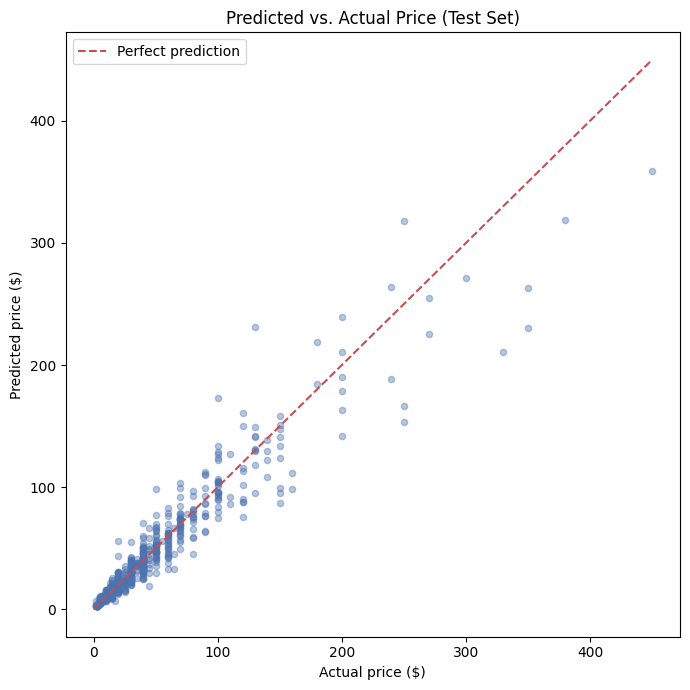

In [206]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test_real, y_test_pred_real, alpha=0.4, s=20, color='#4c72b0')

max_val = max(y_test_real.max(), y_test_pred_real.max())
plt.plot([0, max_val], [0, max_val], color='#c44e52', linestyle='--', linewidth=1.5, label='Perfect prediction')

plt.xlabel('Actual price ($)')
plt.ylabel('Predicted price ($)')
plt.title('Predicted vs. Actual Price (Test Set)')
plt.legend()
plt.tight_layout()
plt.savefig('pred_vs_actual.png', dpi=150)
plt.show()

### Residual Distribution (Test Set)

The residuals (actual, predicted price) form a sharp, tall peak centered almost exactly at zero, with the large majority of predictions falling within roughly ~\$10 of the true price, strong evidence the model is accurate and largely unbiased across most of the data. Long, thin tails extend out to roughly ~$100, reflecting the harder-to-predict, higher-priced sets identified in the scatterplot above. These tails are fairly symmetric, though slightly more pronounced on the negative side (overprediction), reinforcing that the model's occasional larger errors are concentrated at the expensive end of the price range rather than spread randomly throughout the dataset.

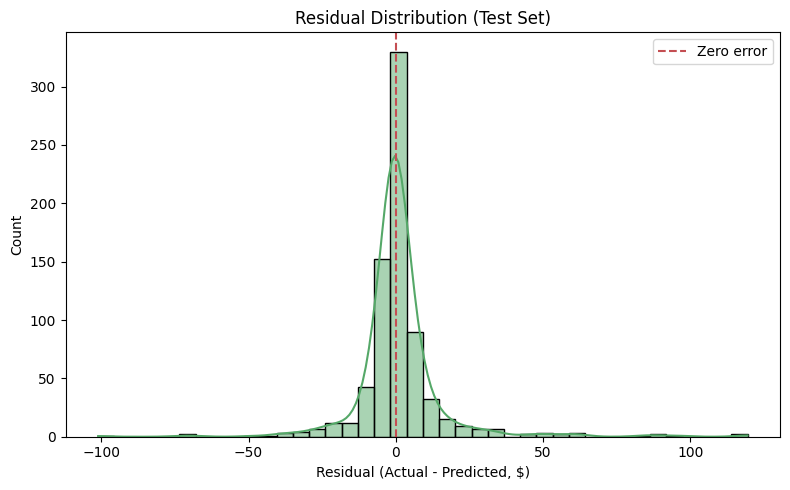

Mean residual: 1.09
Median residual: -0.10


In [207]:
residuals = y_test_real - y_test_pred_real

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=40, kde=True, color='#55a868')
plt.axvline(0, color='#c44e52', linestyle='--', linewidth=1.5, label='Zero error')
plt.xlabel('Residual (Actual - Predicted, $)')
plt.ylabel('Count')
plt.title('Residual Distribution (Test Set)')
plt.legend()
plt.tight_layout()
plt.savefig('residuals.png', dpi=150)
plt.show()

print(f"Mean residual: {residuals.mean():.2f}")
print(f"Median residual: {residuals.median():.2f}")

### Known vs. Predicted Price Distributions

Comparing the density of known prices against the model's predicted prices (log scale) shows both distributions share the same general right-skewed shape, but the predicted distribution is shifted noticeably lower and has a shorter high-price tail. This is not indicative of a systematic prediction bias, as manual inspection of the missing-price rows (see previous section) showed this subgroup is disproportionately composed of older, likely discontinued sets and generic/bulk products (e.g., brick boxes, basic vehicles), rather than flagship or licensed sets. Since undocumented pricing appears concentrated among sets that are no longer sold or were never prominent retail items, it is expected that this subgroup would trend toward lower, more uniform prices compared to the known-price population as sets still tracked with pricing data tend to include more current, premium, and licensed products. A manual cross-check of one high-piece-count prediction (LEGO XXL 2000 Barrel, predicted \$130.86) against a real-world market listing (~\$111) further supports that the model's estimates for this subgroup are reasonable and grounded in real-world pricing behavior.

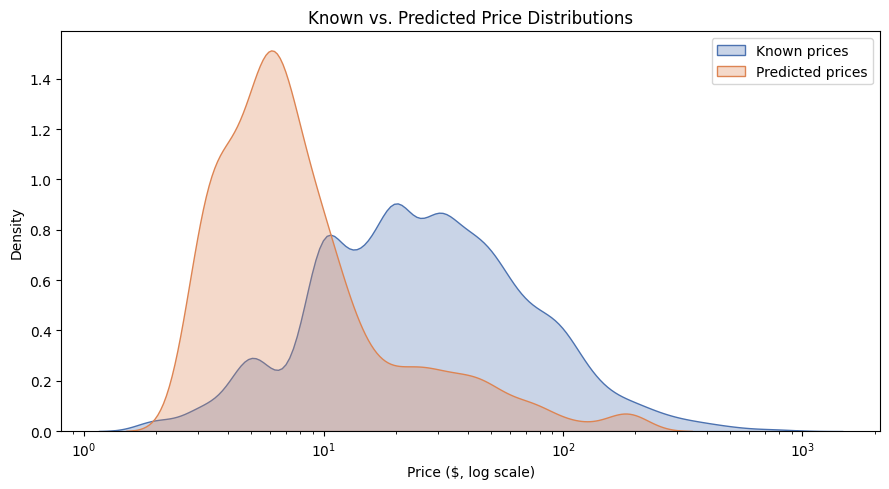

In [208]:
plt.figure(figsize=(9, 5))
sns.kdeplot(known_price_df['US_retailPrice'], label='Known prices', color='#4c72b0', fill=True, alpha=0.3, log_scale=True)
sns.kdeplot(missing_price_df['predicted_US_retailPrice'], label='Predicted prices', color='#dd8452', fill=True, alpha=0.3, log_scale=True)
plt.xlabel('Price ($, log scale)')
plt.ylabel('Density')
plt.title('Known vs. Predicted Price Distributions')
plt.legend()
plt.tight_layout()
plt.savefig('known_vs_predicted_dist.png', dpi=150)
plt.show()

## **Conclusions**

### Summary

This project set out to predict missing US retail prices for LEGO sets using an Artificial Neural Network. Rather than treating this as a straightforward imputation task, extensive EDA revealed that the dataset conflates several structurally different populations: buildable sets, books, merchandise, blind-bag bundles, and educational kits, each with distinct pricing logic. Missingness itself was found to be non-random: driven primarily by a historical data-collection boundary (sets released before ~2005 are almost entirely unpriced) and by category-level differences in what "price" and "pieces" even mean for a given product type.

Rather than imputing across this heterogeneous population, the modeling dataset was deliberately scoped to standard buildable sets (`category == 'Normal'`) released in 2007 or later, with a small number of additional structurally inconsistent rows (e.g., the `Education` theme, mixing full kits with individually-priced components) excluded based on evidence uncovered during EDA. This scoping decision, grounded in data and not in convenience, was the single most consequential step in the pipeline, and is what made the final model's strong performance possible.

### Results

An `MLPRegressor` trained on `pieces`, `minifigs`, `agerange_min`, `year`, and theme-based categorical features achieved:
- **R² of 0.948** on the held-out test set
- **Mean Absolute Error of $7.36**
- Consistent performance between validation and test sets, indicating no overfitting

The model performs strongly across the bulk of the price range (under ~\$150) and moderately overpredicts for higher-priced, less-common sets, an expected limitation given the relative scarcity of expensive sets in the training data.

Applying the trained model to the 1,740 sets with genuinely missing prices produced predictions with a plausible, right-skewed distribution, shifted lower than the known-price population. Manual inspection confirmed this reflects a real compositional difference: the missing-price subgroup is disproportionately made up of older, discontinued, and generic/bulk products rather than current flagship or licensed sets, which is consistent with the same historical data-collection gap identified during EDA. A spot-check against a real-world market listing further supported the plausibility of the model's estimates.

### Limitations

- **Pre-2005 sets remain out of scope.** These sets are almost universally unpriced in both the source dataset and in Brickset's own records (used for an attempted real-data backfill), suggesting this is a genuine historical data-availability gap rather than a solvable collection issue. Predicting their prices with any confidence was not attempted.
- **Non-`Normal` categories (Gear, Books, Random, Collections, and similar) were excluded**, since their pricing follows fundamentally different logic (licensing, bulk contents, page count) unrelated to piece count. This model does not generalize to those product types.
- **Prediction accuracy decreases for high-priced, low-frequency sets**, a known consequence of training on a right-skewed target distribution.
- **`subtheme` was dropped** due to high cardinality and missingness; it's possible some residual predictive signal was left unused.

### Possible Future Work

- Extend the analysis to other product categories (Gear, Books) with feature sets tailored to their actual pricing drivers.
- Investigate whether external sources beyond Brickset (e.g., regional retailers, secondary markets) could help recover pre-2005 pricing.
- Explore ensemble or gradient-boosted alternatives to compare against the ANN's performance, particularly for the high-price tail where the neural network showed the most error.
- Revisit `subtheme` with a more targeted imputation or embedding-based encoding to test whether it adds meaningful signal beyond `theme`/`themeGroup`.